# Multimodal Fine Tuned Representations on LLaVA: Layerwise vs Headwise Analysis

In [5]:
import pandas as pd
import os
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from typing import Dict, Tuple
from scripts.analyze_heads_representations import plot_similarity_measure_heatmap

# Set style for better plots
plt.style.use("default")
sns.set_palette("tab10")


## Functions

In [42]:
def compute_layers_stats_across_heads(df):
    return df.apply(
        lambda row: pd.Series(
            {
                "mean": row.mean(),
                "std": row.std(),
                "min": row.min(),
                "max": row.max(),
                "median": row.median(),
            }
        ),
        axis=1,
    )


def plot_similarity_measure(
    data_dict: Dict[str, pd.DataFrame],
    title: str,
    measure: str,
    figsize: Tuple[int, int] = (12, 6),
):
    """
    Parameters:
    - data_dict: dictionary with dataset names as keys and DataFrames as values
    - figsize: tuple, size of the figure
    - title: plot title
    """

    plt.figure(figsize=figsize)
    colors = plt.cm.tab10(np.linspace(0, 1, 10)[:5])  # Get distinct colors
    for idx, (dataset_name, df) in enumerate(data_dict.items()):
        marker = "o" if "MH" in dataset_name else "x"
        linestyle = "solid" if "MH" in dataset_name else "--"
        plt.plot(
            df.index.astype(int),
            df["data"].to_numpy(),
            label=dataset_name,
            marker=marker,
            color=colors[idx % len(colors)],
            linestyle=linestyle,
        )

    plt.xlabel("Layer")
    plt.ylabel(measure)
    plt.ylim(0, 1)
    plt.title(f"{title}")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

def plot_diff_mean_similarity(
    data_dict: Dict[str, pd.DataFrame],
    title: str,
    measure: str,
    figsize: Tuple[int, int] = (12, 6),
):
    plt.figure(figsize=figsize)
    
    y_min = 0
    y_max = 1
    for dataset_name, df in data_dict.items():
        x = df.index.astype(int)
        y = df["data"].to_numpy()   
        y_min = min(y_min, y.min())
        plt.plot(
            x,
            y,
            label=dataset_name,
            linestyle='dashed',
            marker='o'
        )

    plt.xlabel("Layer")
    plt.ylabel(f"{measure} (difference for mean @ heads)")
    plt.title(f"{title}")
    plt.legend()
    plt.ylim(y_min, y_max)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

## Analysis

In [43]:
def make_plots(
    measure,
    sim_measure_matrix_cocoimg="cocoqa_captioning_restval_heads_representations_layer-all_token-last_pproj_img-qa_chat_gtxt_cfm_ds2500_s42_batch1_maxk-30_reps-ds2500.parquet",
    sim_measure_matrix_cocotxt="cocoqa_captioning_restval_heads_representations_layer-all_token-last_pproj_txt-qa_chat_gtxt_cfm_ds2500_s42_batch1_maxk-30_reps-ds2500.parquet",
    sim_measure_matrix_mmlu="mmlu_test_heads_representations_layer-all_token-last_pproj_txt-qa_chat_qitype-singular_gtxt_cfm_ds2500_s42_batch1_maxk-30_reps-ds2500.parquet",
    sim_measure_matrix_scienceqa_img="ScienceQA_test_heads_representations_layer-all_token-last_pproj_img-qa_chat_qitype-singular_gtxt_cfm_s42_batch1_maxk-30.parquet",
    sim_measure_matrix_scienceqa_txt="ScienceQA_test_heads_representations_layer-all_token-last_pproj_txt-qa_chat_qitype-singular_gtxt_cfm_s42_batch1_maxk-30.parquet",
    sim_measure_layerwise_cocoimg="cocoqa_captioning_restval_layers_representations_layer-all_token-last_pproj_img-qa_chat_gtxt_cfm_ds2500_s42_maxk-30_reps-ds2500.csv",
    sim_measure_layerwise_cocotxt="cocoqa_captioning_restval_layers_representations_layer-all_token-last_pproj_txt-qa_chat_gtxt_cfm_ds2500_s42_maxk-30_reps-ds2500.csv",
    sim_measure_layerwise_mmlu="mmlu_test_layers_representations_layer-all_token-last_pproj_txt-qa_chat_qitype-singular_gtxt_cfm_ds2500_s42_maxk-30_reps-ds2500.csv",
    sim_measure_layerwise_scienceqa_img="ScienceQA_test_layers_representations_layer-all_token-last_pproj_img-qa_chat_qitype-singular_gtxt_cfm_s42_maxk-30.csv",
    sim_measure_layerwise_scienceqa_txt="ScienceQA_test_layers_representations_layer-all_token-last_pproj_txt-qa_chat_qitype-singular_gtxt_cfm_s42_maxk-30.csv",
):
    sim_measure_matrix_dir = f"../results/{measure}/heads_representations"
    sim_measure_layerwise_dir = f"../results/{measure}/layers_representations"
    models_info = "llava-hf_llava-1.5-7b-hf_vs_lmsys_vicuna-7b-v1.5"

    sim_measure_matrix_cocotxt_path = os.path.join(
        sim_measure_matrix_dir, f"{models_info}_{sim_measure_matrix_cocotxt}"
    )
    sim_measure_matrix_cocoimg_path = os.path.join(
        sim_measure_matrix_dir, f"{models_info}_{sim_measure_matrix_cocoimg}"
    )
    sim_measure_matrix_mmlu_path = os.path.join(
        sim_measure_matrix_dir, f"{models_info}_{sim_measure_matrix_mmlu}"
    )
    sim_measure_matrix_scienceqa_txt_path = os.path.join(
        sim_measure_matrix_dir, f"{models_info}_{sim_measure_matrix_scienceqa_txt}"
    )
    sim_measure_matrix_scienceqa_img_path = os.path.join(
        sim_measure_matrix_dir, f"{models_info}_{sim_measure_matrix_scienceqa_img}"
    )

    sim_measure_layerwise_cocoimg_path = os.path.join(
        sim_measure_layerwise_dir, f"{models_info}_{sim_measure_layerwise_cocoimg}"
    )
    sim_measure_layerwise_cocotxt_path = os.path.join(
        sim_measure_layerwise_dir, f"{models_info}_{sim_measure_layerwise_cocotxt}"
    )
    sim_measure_layerwise_mmlu_path = os.path.join(
        sim_measure_layerwise_dir, f"{models_info}_{sim_measure_layerwise_mmlu}"
    )
    sim_measure_layerwise_scienceqa_txt_path = os.path.join(
        sim_measure_layerwise_dir,
        f"{models_info}_{sim_measure_layerwise_scienceqa_txt}",
    )
    sim_measure_layerwise_scienceqa_img_path = os.path.join(
        sim_measure_layerwise_dir,
        f"{models_info}_{sim_measure_layerwise_scienceqa_img}",
    )

    heads_rep_mmlu_df = pd.read_parquet(sim_measure_matrix_mmlu_path)
    heads_rep_scienceqa_text_df = pd.read_parquet(sim_measure_matrix_scienceqa_txt_path)
    heads_rep_scienceqa_images_df = pd.read_parquet(
        sim_measure_matrix_scienceqa_img_path
    )
    heads_rep_cocoqa_text_df = pd.read_parquet(sim_measure_matrix_cocotxt_path)
    heads_rep_cocoqa_image_df = pd.read_parquet(sim_measure_matrix_cocoimg_path)

    layers_rep_mmlu_df = pd.read_csv(sim_measure_layerwise_mmlu_path, index_col=0)
    layers_rep_scienceqa_text_df = pd.read_csv(
        sim_measure_layerwise_scienceqa_txt_path, index_col=0
    )
    layers_rep_scienceqa_images_df = pd.read_csv(
        sim_measure_layerwise_scienceqa_img_path, index_col=0
    )
    layers_rep_cocoqa_text_df = pd.read_csv(
        sim_measure_layerwise_cocotxt_path, index_col=0
    )
    layers_rep_cocoqa_image_df = pd.read_csv(
        sim_measure_layerwise_cocoimg_path, index_col=0
    )

    heads_rep_scienceqa_text_minus_images_df = (
        heads_rep_scienceqa_text_df - heads_rep_scienceqa_images_df
    )
    heads_rep_cocoqa_text_minus_images_df = (
        heads_rep_cocoqa_text_df - heads_rep_cocoqa_image_df
    )

    mmlu_layers_stats_across_heads = compute_layers_stats_across_heads(
        heads_rep_mmlu_df
    )
    scienceqa_text_layers_stats_across_heads = compute_layers_stats_across_heads(
        heads_rep_scienceqa_text_df
    )
    scienceqa_images_layers_stats_across_heads = compute_layers_stats_across_heads(
        heads_rep_scienceqa_images_df
    )
    cocoqa_text_layers_stats_across_heads = compute_layers_stats_across_heads(
        heads_rep_cocoqa_text_df
    )
    cocoqa_image_layers_stats_across_heads = compute_layers_stats_across_heads(
        heads_rep_cocoqa_image_df
    )

    layerwise_measure_data_dict = {
        "COCOQA IMG LW": layers_rep_cocoqa_image_df.rename(columns={measure: "data"}),
        "COCOQA TXT LW": layers_rep_cocoqa_text_df.rename(columns={measure: "data"}),
        "MMLU LW": layers_rep_mmlu_df.rename(columns={measure: "data"}),
        "SQA IMG LW": layers_rep_scienceqa_images_df.rename(columns={measure: "data"}),
        "SQA TXT LW": layers_rep_scienceqa_text_df.rename(columns={measure: "data"}),
    }

    heads_measure_data_dict = {
        "COCOQA IMG MH": cocoqa_image_layers_stats_across_heads[["mean"]].rename(
            columns={"mean": "data"}
        ),
        "COCOQA TXT MH": cocoqa_text_layers_stats_across_heads[["mean"]].rename(
            columns={"mean": "data"}
        ),
        "MMLU MH": mmlu_layers_stats_across_heads[["mean"]].rename(
            columns={"mean": "data"}
        ),
        "SQA IMG MH": scienceqa_images_layers_stats_across_heads[["mean"]].rename(
            columns={"mean": "data"}
        ),
        "SQA TXT MH": scienceqa_text_layers_stats_across_heads[["mean"]].rename(
            columns={"mean": "data"}
        ),
    }
    
    diff_mean_similarity_data_dict = {
        # ScienceQA-TXT - ScienceQA-IMG
        "SQA TXT - SQA IMG": heads_measure_data_dict["SQA TXT MH"] - heads_measure_data_dict["SQA IMG MH"],
        # COCOQA-TXT - COCOQA-IMG
        "COCOQA TXT - COCOQA IMG": heads_measure_data_dict["COCOQA TXT MH"] - heads_measure_data_dict["COCOQA IMG MH"],
    }
    
    main_title = "LLaVa 1.5 7B vs Vicuna 1.5 7B"
    
    plot_similarity_measure_heatmap(
        matrix_similarities_df=heads_rep_mmlu_df,
        title=f"{main_title} (MMLU)",
        percentage_threshold=0.1,
        top_p_percent=0.05,
        bottom_p_percent=0.03,
        measure=measure,
    )
    
    plot_similarity_measure_heatmap(
        matrix_similarities_df=heads_rep_scienceqa_text_df,
        title=f"{main_title} (ScienceQA-TXT)",
        percentage_threshold=0.1,
        top_p_percent=0.05,
        bottom_p_percent=0.03,
        measure=measure,
    )
    
    plot_similarity_measure_heatmap(
        matrix_similarities_df=heads_rep_scienceqa_images_df,
        title=f"{main_title} (ScienceQA-IMG)",
        percentage_threshold=0.1,
        top_p_percent=0.05,
        bottom_p_percent=0.03,
        measure=measure,
    )
    
    plot_similarity_measure_heatmap(
        heads_rep_scienceqa_text_minus_images_df,
        title=f"{main_title}" + r" (ScienceQA: $M^{\mathrm{text}}_{l,h} - M^{\mathrm{images}}_{l,h}$)",
        figsize=(16, 9),
        percentage_threshold=0.1,
        top_p_percent=0.05,
        bottom_p_percent=0.03,
        measure=measure,
    )
    
    plot_similarity_measure_heatmap(
        matrix_similarities_df=heads_rep_cocoqa_text_df,
        title=f"{main_title} (COCOQA-TXT)",
        percentage_threshold=0.1,
        top_p_percent=0.05,
        bottom_p_percent=0.03,
        measure=measure,
    )
    
    plot_similarity_measure_heatmap(
        matrix_similarities_df=heads_rep_cocoqa_image_df,
        title=f"{main_title} (COCOQA-IMG)",
        percentage_threshold=0.1,
        top_p_percent=0.05,
        bottom_p_percent=0.03,
        measure=measure,
    )

    plot_similarity_measure_heatmap(
        heads_rep_cocoqa_text_minus_images_df,
        title=f"{main_title}" + r" (COCOQA: $M^{\mathrm{text}}_{l,h} - M^{\mathrm{images}}_{l,h}$)",
        figsize=(16, 9),
        percentage_threshold=0.1,
        top_p_percent=0.05,
        bottom_p_percent=0.03,
        measure=measure,
    )

    plot_similarity_measure(
        data_dict={
            **layerwise_measure_data_dict,
            **heads_measure_data_dict,
        },
        figsize=(10, 6),
        title=f"{main_title}",
        measure=measure,
    )

    plot_similarity_measure(
        data_dict={
            **layerwise_measure_data_dict,
        },
        figsize=(10, 6),
        title=f"{main_title}",
        measure=measure,
    )

    plot_similarity_measure(
        data_dict={
            **heads_measure_data_dict,
        },
        figsize=(10, 6),
        title=f"{main_title}",
        measure=measure,
    )
    
    plot_diff_mean_similarity(
        data_dict={
            **diff_mean_similarity_data_dict,
        },
        figsize=(10, 6),
        title=f"{main_title}",
        measure=measure,
    )

Max neighborhood_overlap: 0.92, Min neighborhood_overlap: 0.11
Min upper bound: 0.4003, Max lower bound: 0.6150
% in upper bound (white): 7.23%, # values: 74
% in lower bound (white): 6.84%, # values: 70
% in bounds (white): 14.06%, # values: 144
Top 5.00% cutoff value: 0.7273
% identified as top p%: 5.08%, # values: 52
Bottom 3.00% cutoff value: 0.1971
% identified as bottom p%: 3.03%, # values: 31
% in top p% (red): 1.27%, # values: 13
% in bottom p% (orange): 2.83%, # values: 29
% in top and bottom p% (red and orange): 4.10%, # values: 42


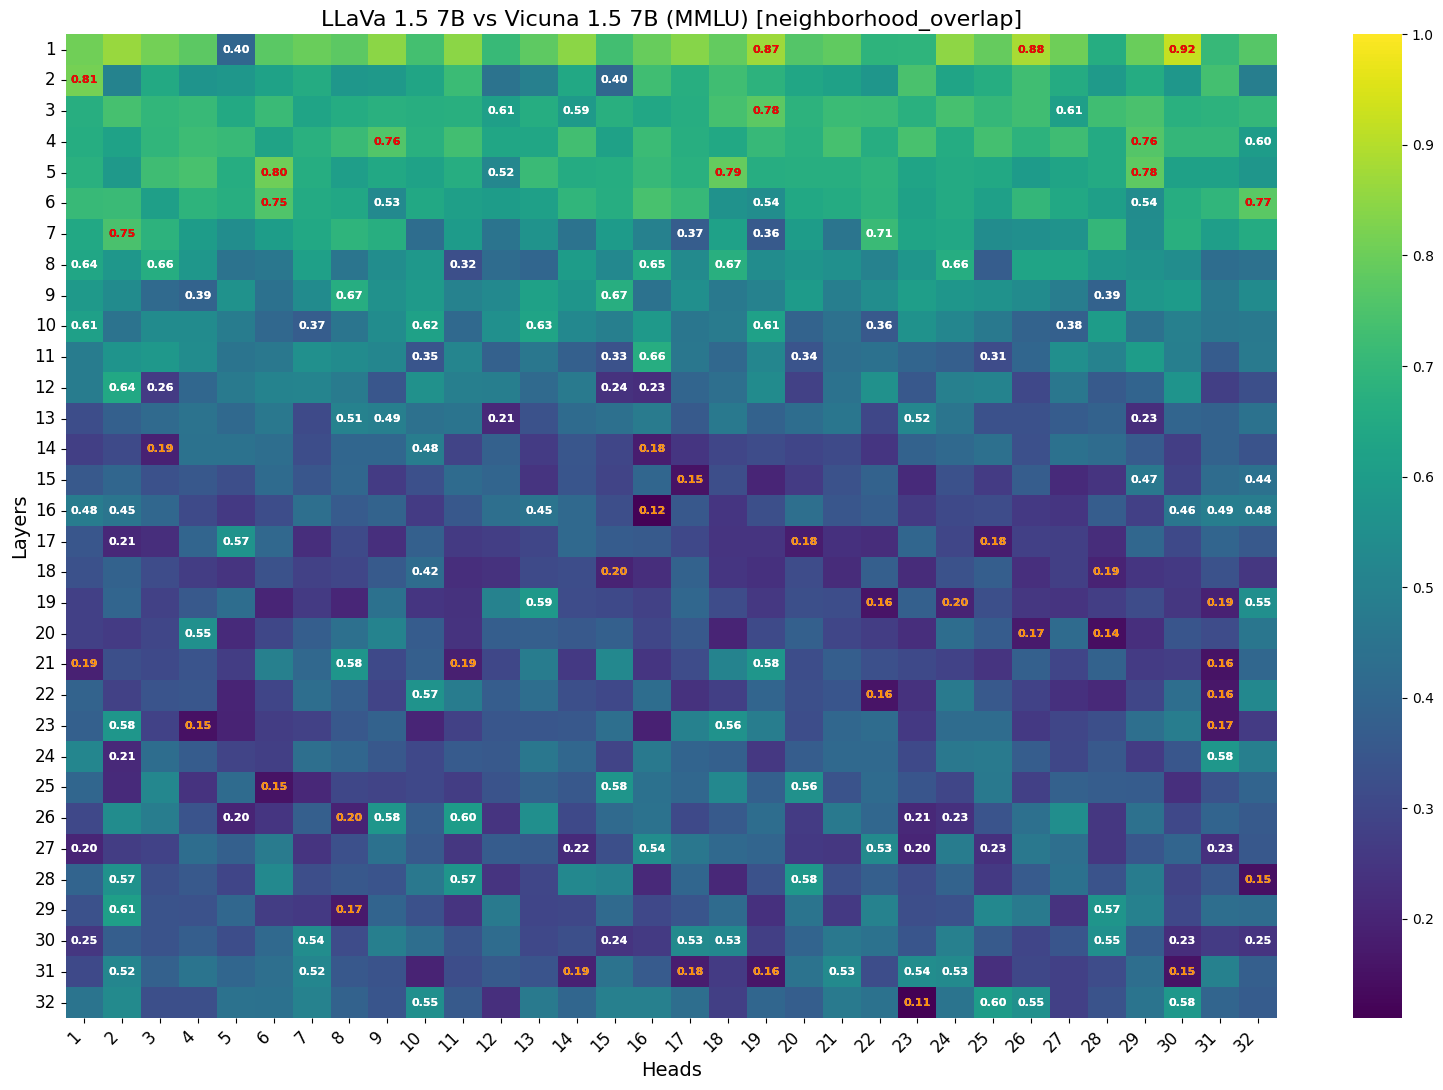

Max neighborhood_overlap: 0.94, Min neighborhood_overlap: 0.19
Min upper bound: 0.5839, Max lower bound: 0.7000
% in upper bound (white): 11.23%, # values: 115
% in lower bound (white): 4.39%, # values: 45
% in bounds (white): 15.62%, # values: 160
Top 5.00% cutoff value: 0.8039
% identified as top p%: 5.08%, # values: 52
Bottom 3.00% cutoff value: 0.4179
% identified as bottom p%: 3.03%, # values: 31
% in top p% (red): 2.73%, # values: 28
% in bottom p% (orange): 1.66%, # values: 17
% in top and bottom p% (red and orange): 4.39%, # values: 45


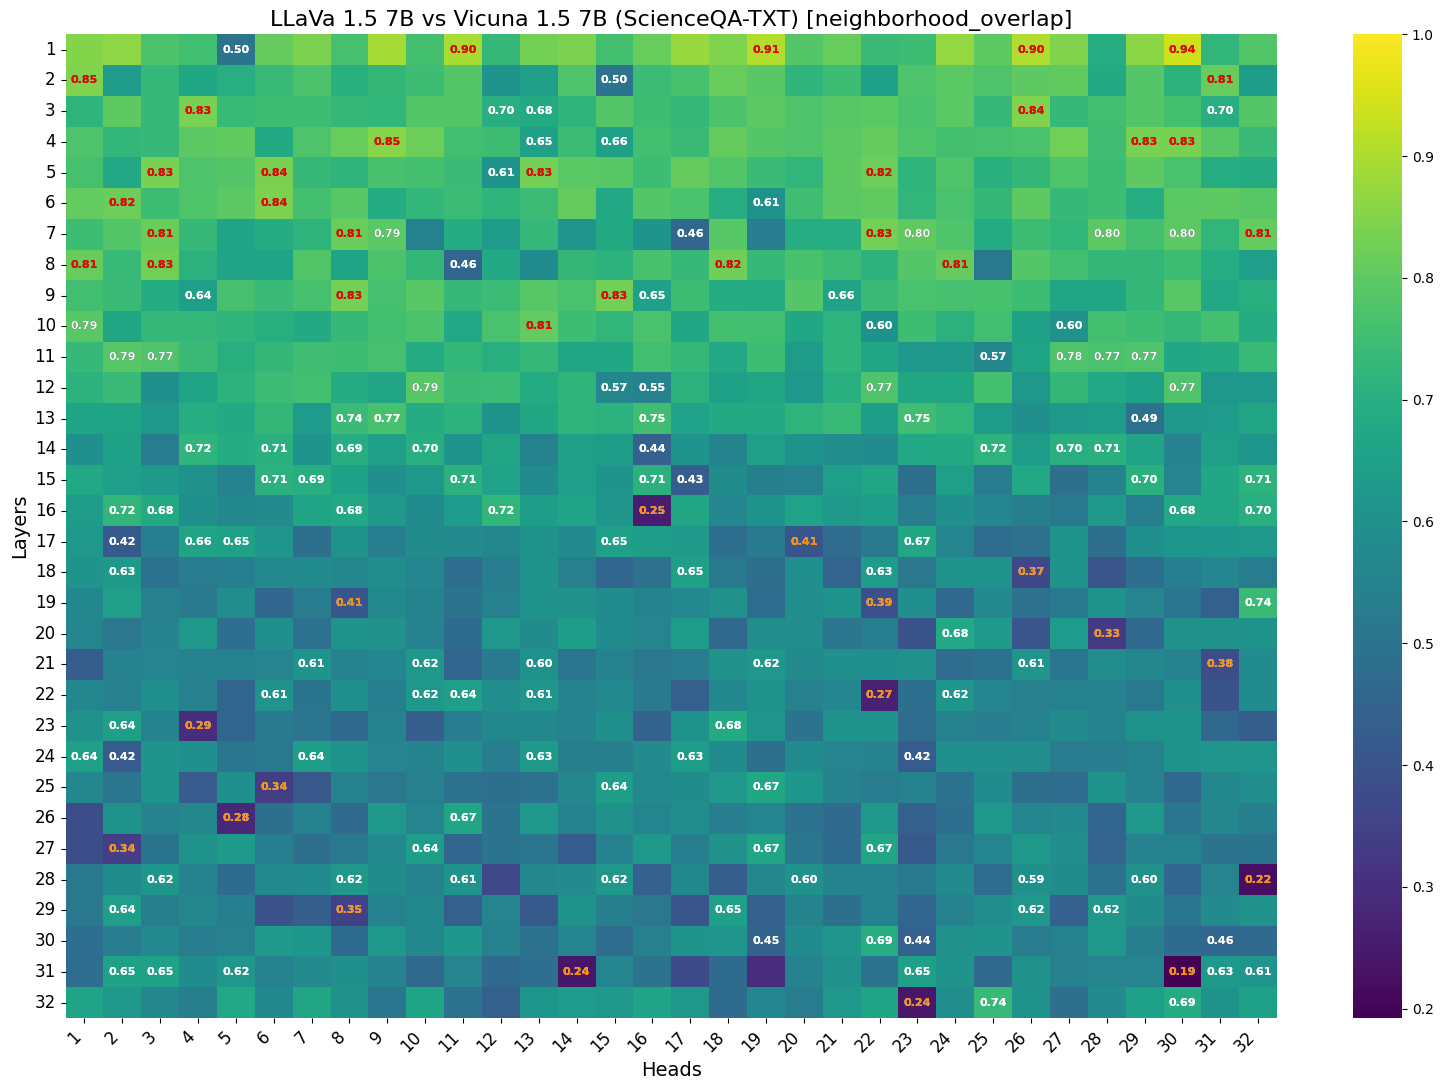

Max neighborhood_overlap: 0.91, Min neighborhood_overlap: 0.20
Min upper bound: 0.4739, Max lower bound: 0.6386
% in upper bound (white): 7.71%, # values: 79
% in lower bound (white): 6.25%, # values: 64
% in bounds (white): 13.96%, # values: 143
Top 5.00% cutoff value: 0.7031
% identified as top p%: 5.08%, # values: 52
Bottom 3.00% cutoff value: 0.2739
% identified as bottom p%: 3.03%, # values: 31
% in top p% (red): 0.59%, # values: 6
% in bottom p% (orange): 2.44%, # values: 25
% in top and bottom p% (red and orange): 3.03%, # values: 31


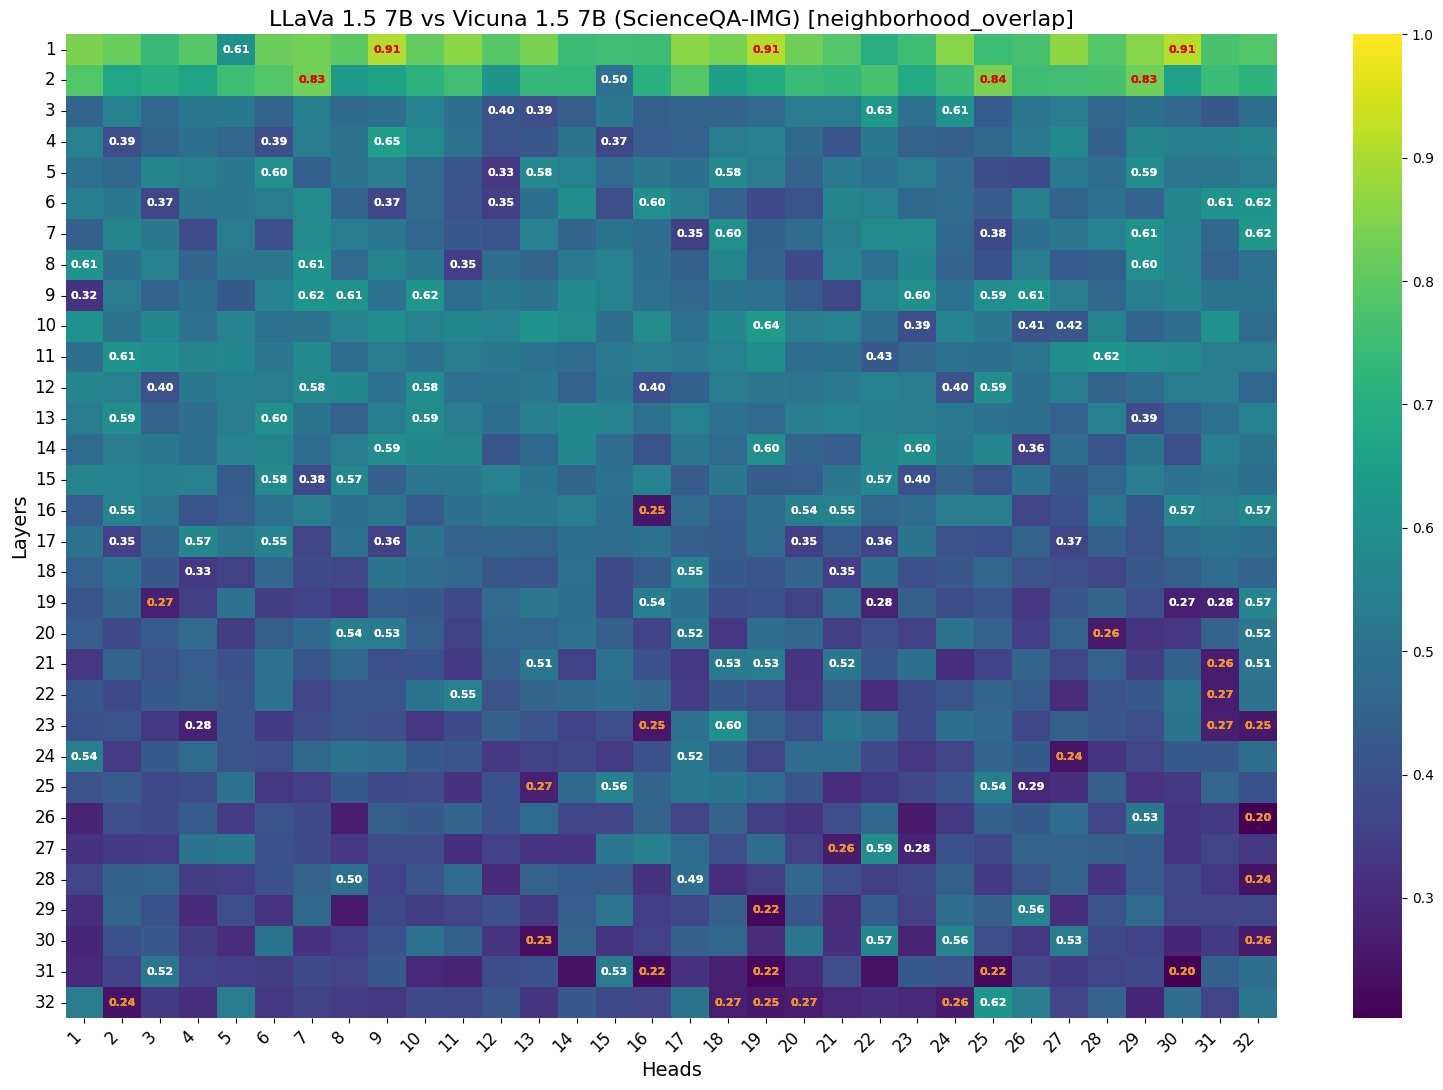

Max neighborhood_overlap: 0.44, Min neighborhood_overlap: -0.12
Min upper bound: 0.1108, Max lower bound: 0.1963
% in upper bound (white): 6.05%, # values: 62
% in lower bound (white): 6.05%, # values: 62
% in bounds (white): 12.11%, # values: 124
Top 5.00% cutoff value: 0.3011
% identified as top p%: 5.08%, # values: 52
Bottom 3.00% cutoff value: -0.0093
% identified as bottom p%: 3.03%, # values: 31
% in top p% (red): 1.86%, # values: 19
% in bottom p% (orange): 0.98%, # values: 10
% in top and bottom p% (red and orange): 2.83%, # values: 29


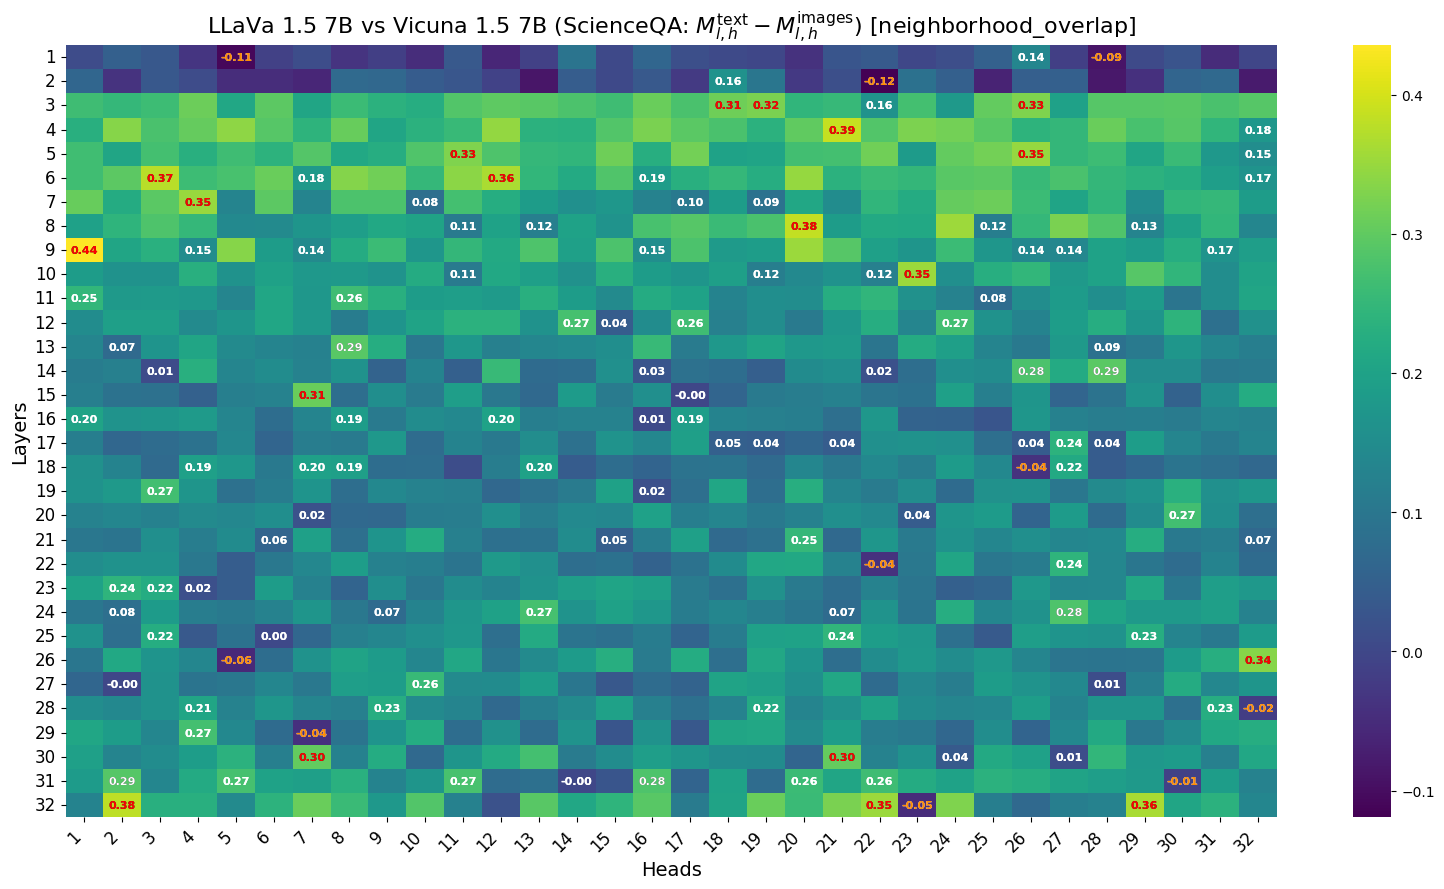

Max neighborhood_overlap: 0.75, Min neighborhood_overlap: 0.03
Min upper bound: 0.1886, Max lower bound: 0.4338
% in upper bound (white): 4.69%, # values: 48
% in lower bound (white): 10.16%, # values: 104
% in bounds (white): 14.84%, # values: 152
Top 5.00% cutoff value: 0.5268
% identified as top p%: 5.18%, # values: 53
Bottom 3.00% cutoff value: 0.0747
% identified as bottom p%: 3.03%, # values: 31
% in top p% (red): 0.49%, # values: 5
% in bottom p% (orange): 2.54%, # values: 26
% in top and bottom p% (red and orange): 3.03%, # values: 31


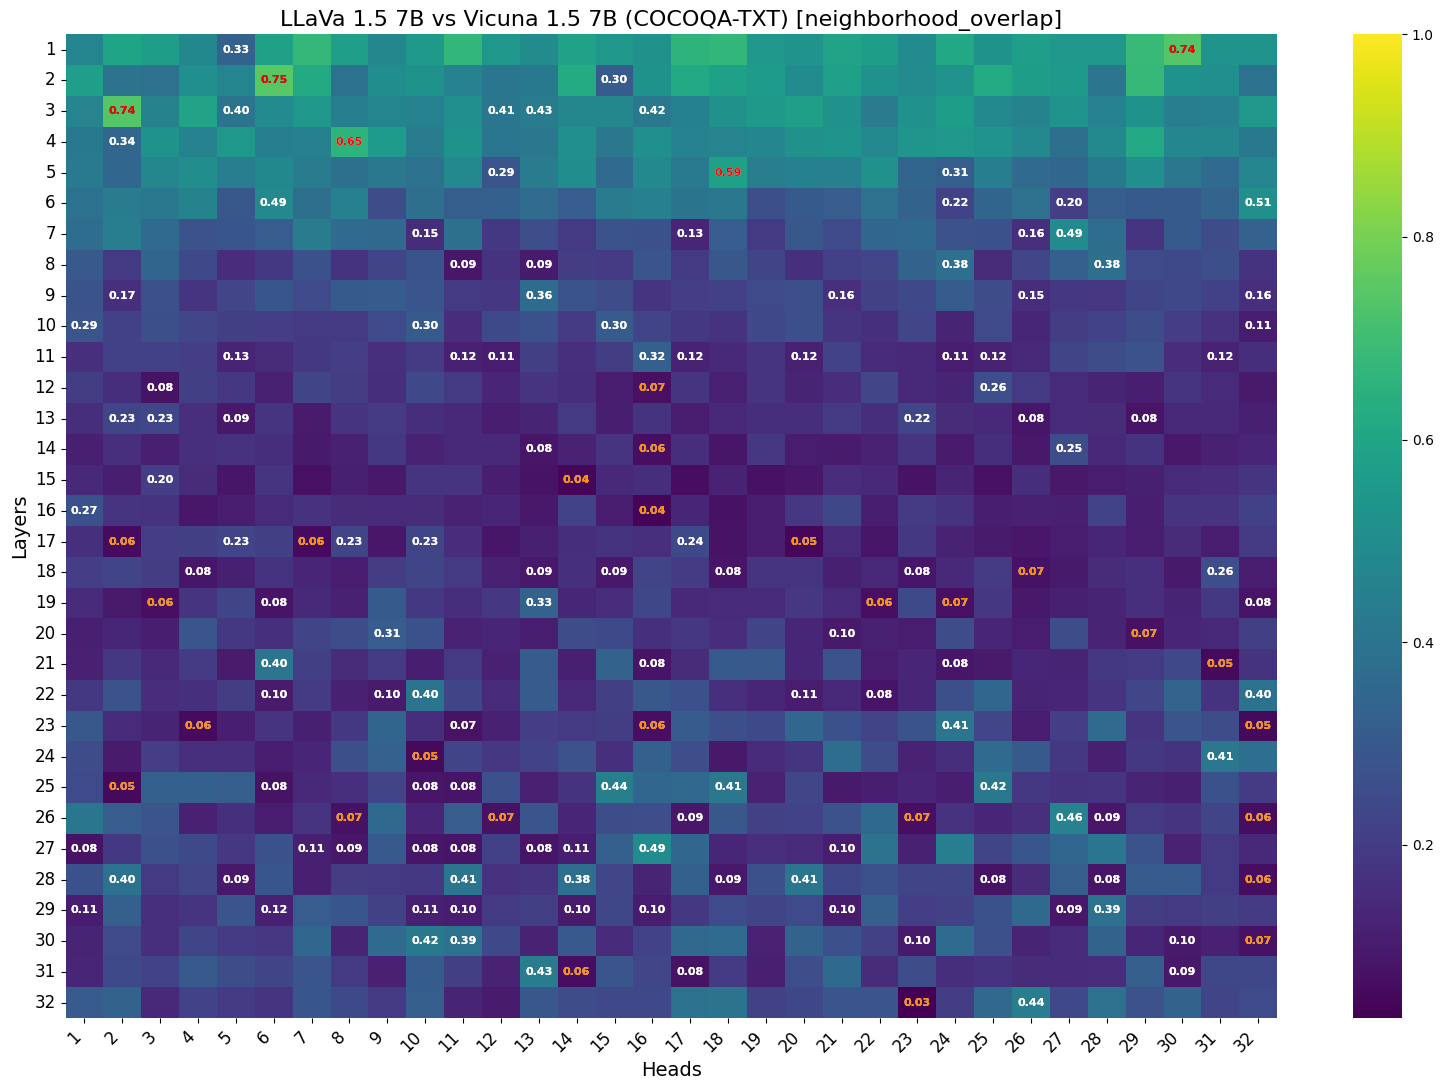

Max neighborhood_overlap: 0.79, Min neighborhood_overlap: 0.03
Min upper bound: 0.1220, Max lower bound: 0.3899
% in upper bound (white): 5.86%, # values: 60
% in lower bound (white): 12.40%, # values: 127
% in bounds (white): 18.26%, # values: 187
Top 5.00% cutoff value: 0.4129
% identified as top p%: 5.08%, # values: 52
Bottom 3.00% cutoff value: 0.0453
% identified as bottom p%: 3.03%, # values: 31
% in top p% (red): 0.98%, # values: 10
% in bottom p% (orange): 2.44%, # values: 25
% in top and bottom p% (red and orange): 3.42%, # values: 35


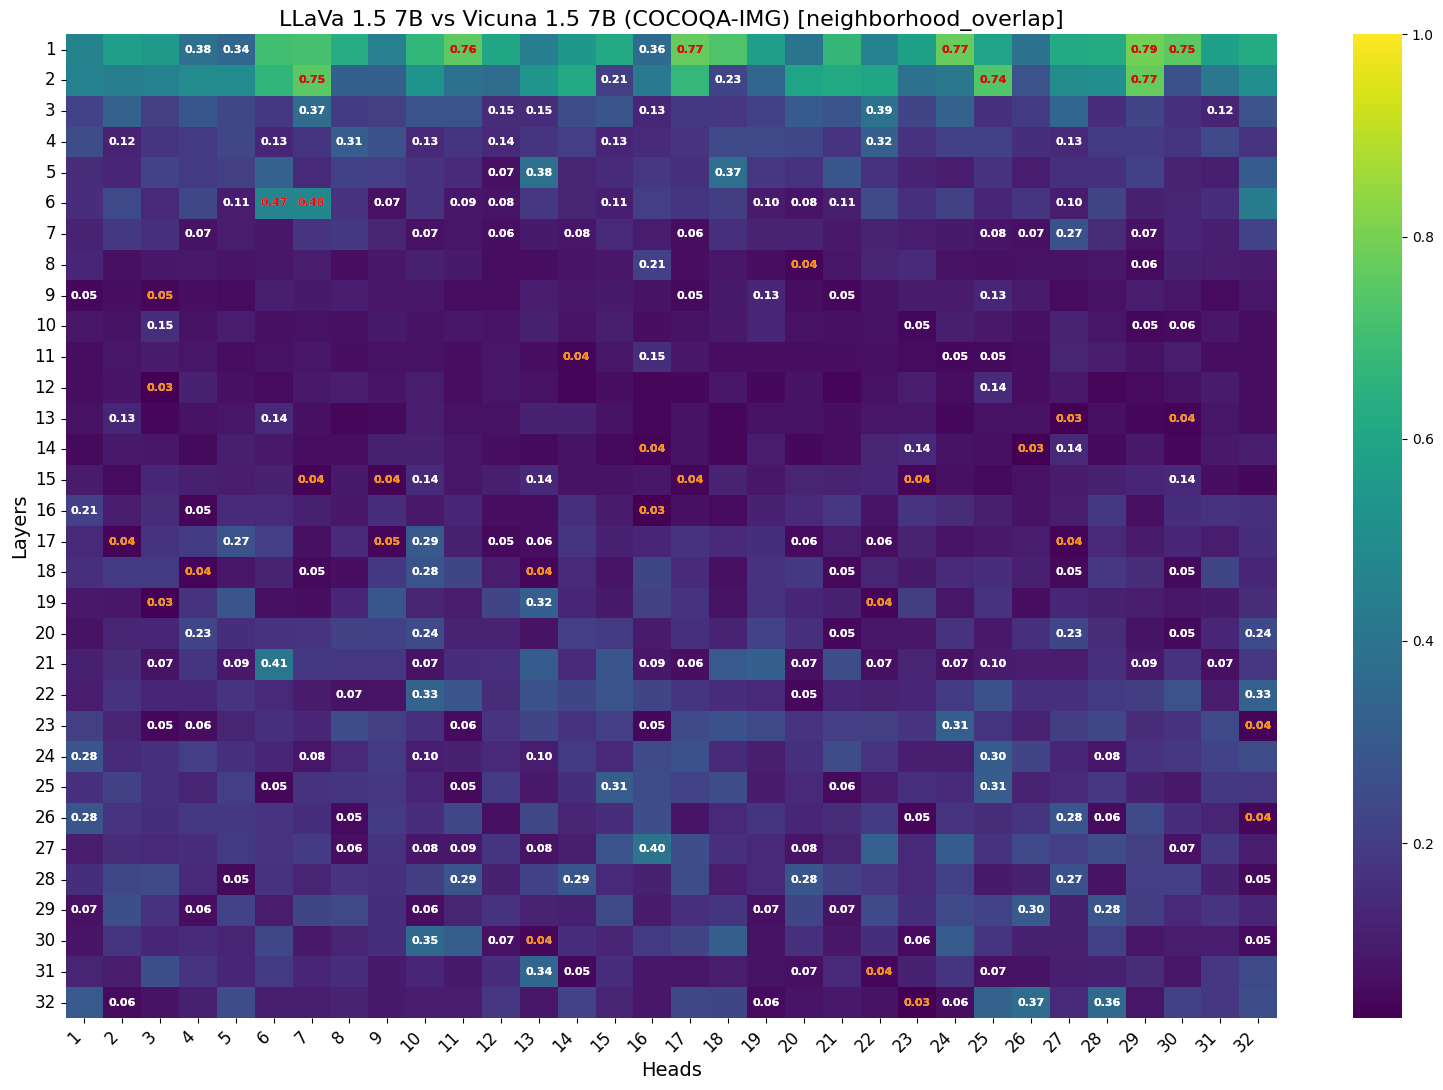

Max neighborhood_overlap: 0.42, Min neighborhood_overlap: -0.16
Min upper bound: 0.0652, Max lower bound: 0.1933
% in upper bound (white): 4.69%, # values: 48
% in lower bound (white): 6.74%, # values: 69
% in bounds (white): 11.43%, # values: 117
Top 5.00% cutoff value: 0.2763
% identified as top p%: 5.08%, # values: 52
Bottom 3.00% cutoff value: -0.0645
% identified as bottom p%: 3.03%, # values: 31
% in top p% (red): 1.07%, # values: 11
% in bottom p% (orange): 1.66%, # values: 17
% in top and bottom p% (red and orange): 2.73%, # values: 28


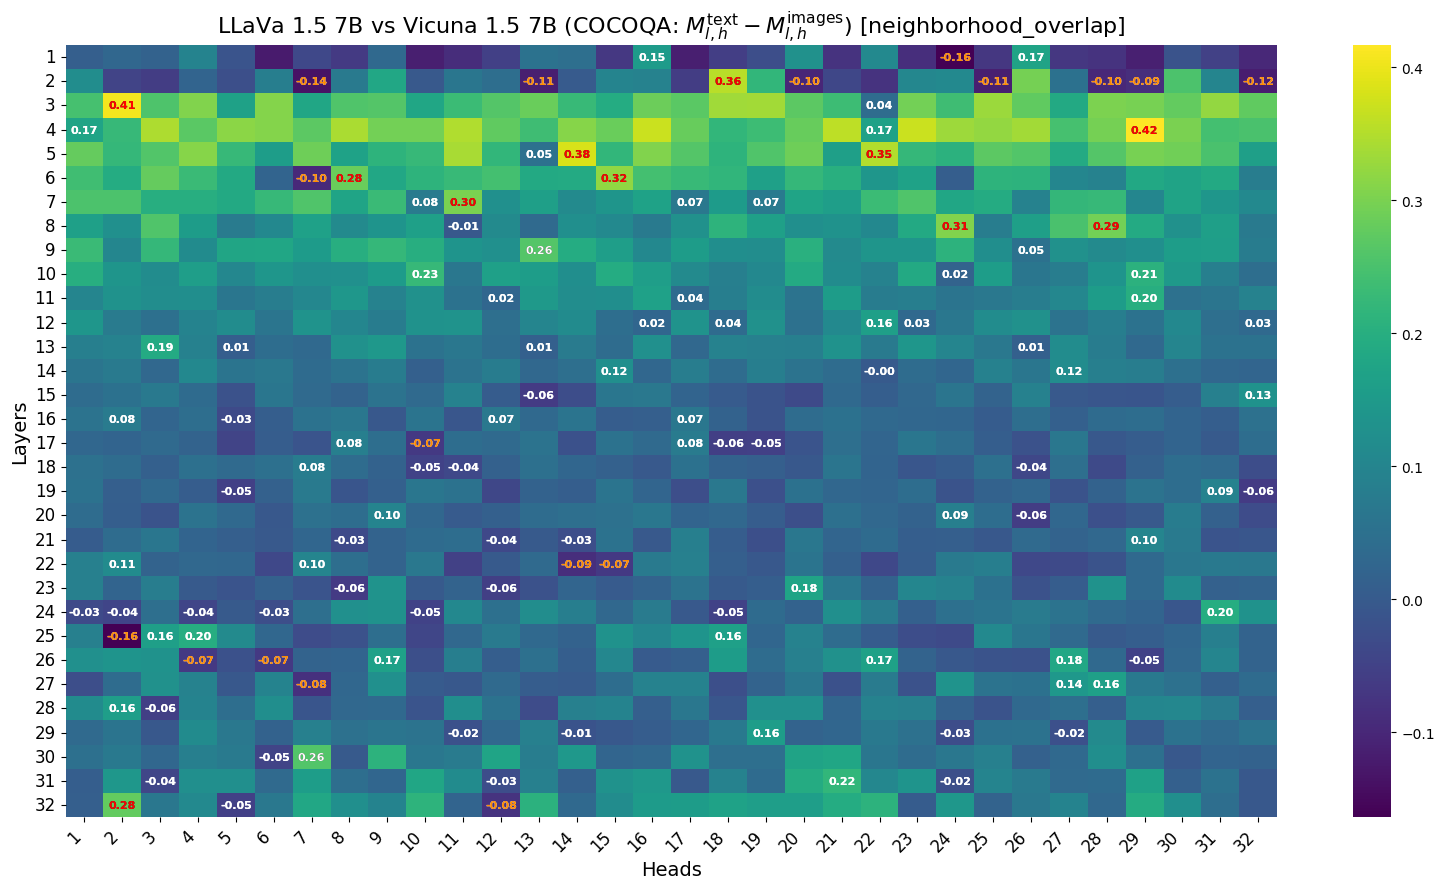

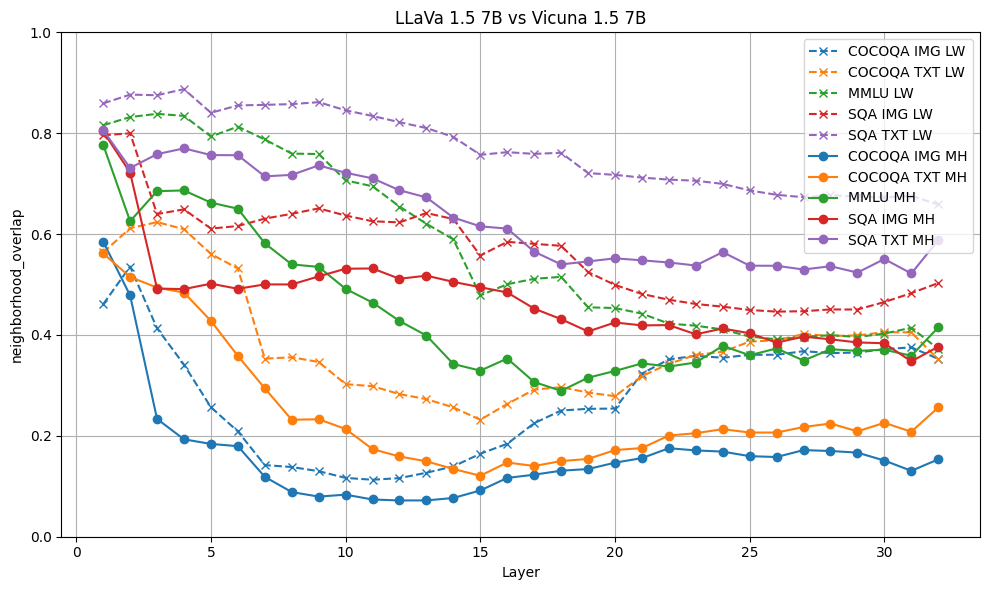

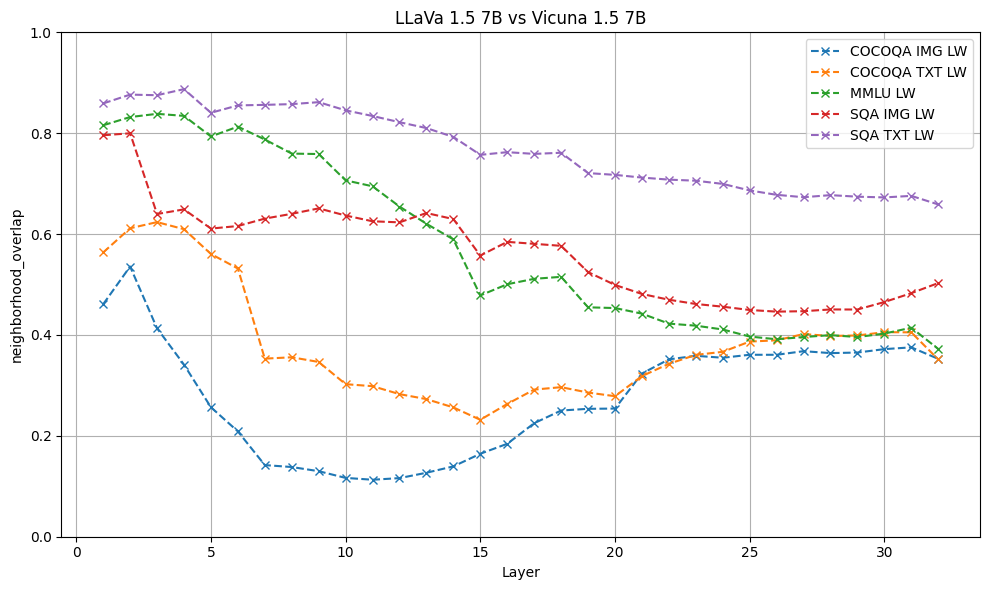

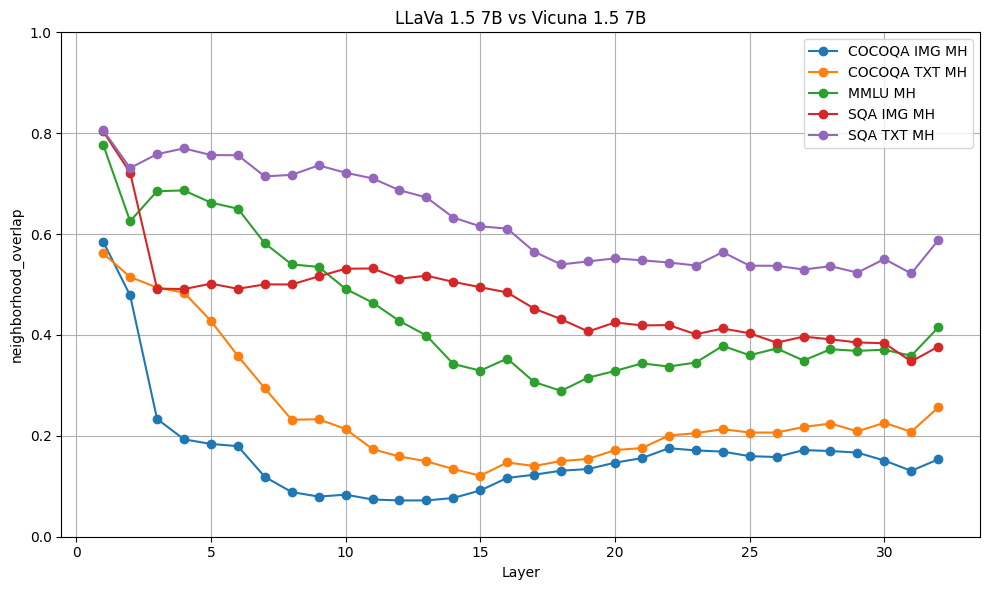

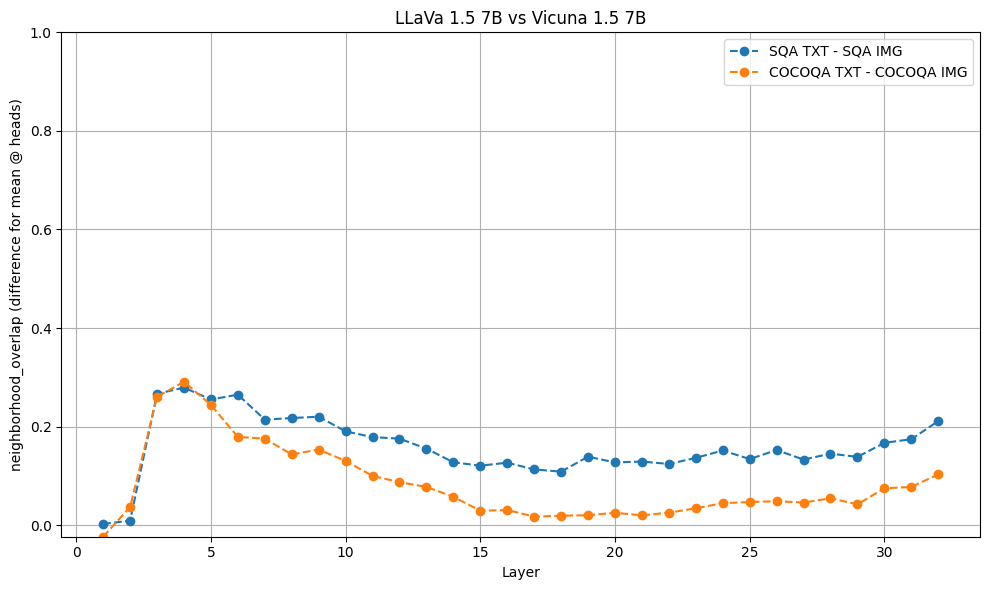

In [44]:
make_plots(
    measure="neighborhood_overlap", 
    sim_measure_matrix_cocoimg="cocoqa_captioning_restval_heads_representations_layer-all_token-last_pproj_img-qa_chat_gtxt_cfm_ds2500_s42_batch1_maxk-30_reps-ds2500.parquet",
    sim_measure_matrix_cocotxt="cocoqa_captioning_restval_heads_representations_layer-all_token-last_pproj_txt-qa_chat_gtxt_cfm_ds2500_s42_batch1_maxk-30_reps-ds2500.parquet",
    sim_measure_matrix_mmlu="mmlu_test_heads_representations_layer-all_token-last_pproj_txt-qa_chat_qitype-singular_gtxt_cfm_ds2500_s42_batch1_maxk-30_reps-ds2500.parquet",
    sim_measure_matrix_scienceqa_img="ScienceQA_test_heads_representations_layer-all_token-last_pproj_img-qa_chat_qitype-singular_gtxt_cfm_s42_batch1_maxk-30.parquet",
    sim_measure_matrix_scienceqa_txt="ScienceQA_test_heads_representations_layer-all_token-last_pproj_txt-qa_chat_qitype-singular_gtxt_cfm_s42_batch1_maxk-30.parquet",
    sim_measure_layerwise_cocoimg="cocoqa_captioning_restval_layers_representations_layer-all_token-last_pproj_img-qa_chat_gtxt_cfm_ds2500_s42_maxk-30_reps-ds2500.csv",
    sim_measure_layerwise_cocotxt="cocoqa_captioning_restval_layers_representations_layer-all_token-last_pproj_txt-qa_chat_gtxt_cfm_ds2500_s42_maxk-30_reps-ds2500.csv",
    sim_measure_layerwise_mmlu="mmlu_test_layers_representations_layer-all_token-last_pproj_txt-qa_chat_qitype-singular_gtxt_cfm_ds2500_s42_maxk-30_reps-ds2500.csv",
    sim_measure_layerwise_scienceqa_img="ScienceQA_test_layers_representations_layer-all_token-last_pproj_img-qa_chat_qitype-singular_gtxt_cfm_s42_maxk-30.csv",
    sim_measure_layerwise_scienceqa_txt="ScienceQA_test_layers_representations_layer-all_token-last_pproj_txt-qa_chat_qitype-singular_gtxt_cfm_s42_maxk-30.csv",
)

Max linear_cka: 1.00, Min linear_cka: 0.26
Min upper bound: 0.7070, Max lower bound: 0.9211
% in upper bound (white): 13.96%, # values: 143
% in lower bound (white): 5.08%, # values: 52
% in bounds (white): 19.04%, # values: 195
Top 5.00% cutoff value: 0.9631
% identified as top p%: 5.08%, # values: 52
Bottom 3.00% cutoff value: 0.4252
% identified as bottom p%: 3.03%, # values: 31
% in top p% (red): 4.79%, # values: 49
% in bottom p% (orange): 2.05%, # values: 21
% in top and bottom p% (red and orange): 6.84%, # values: 70


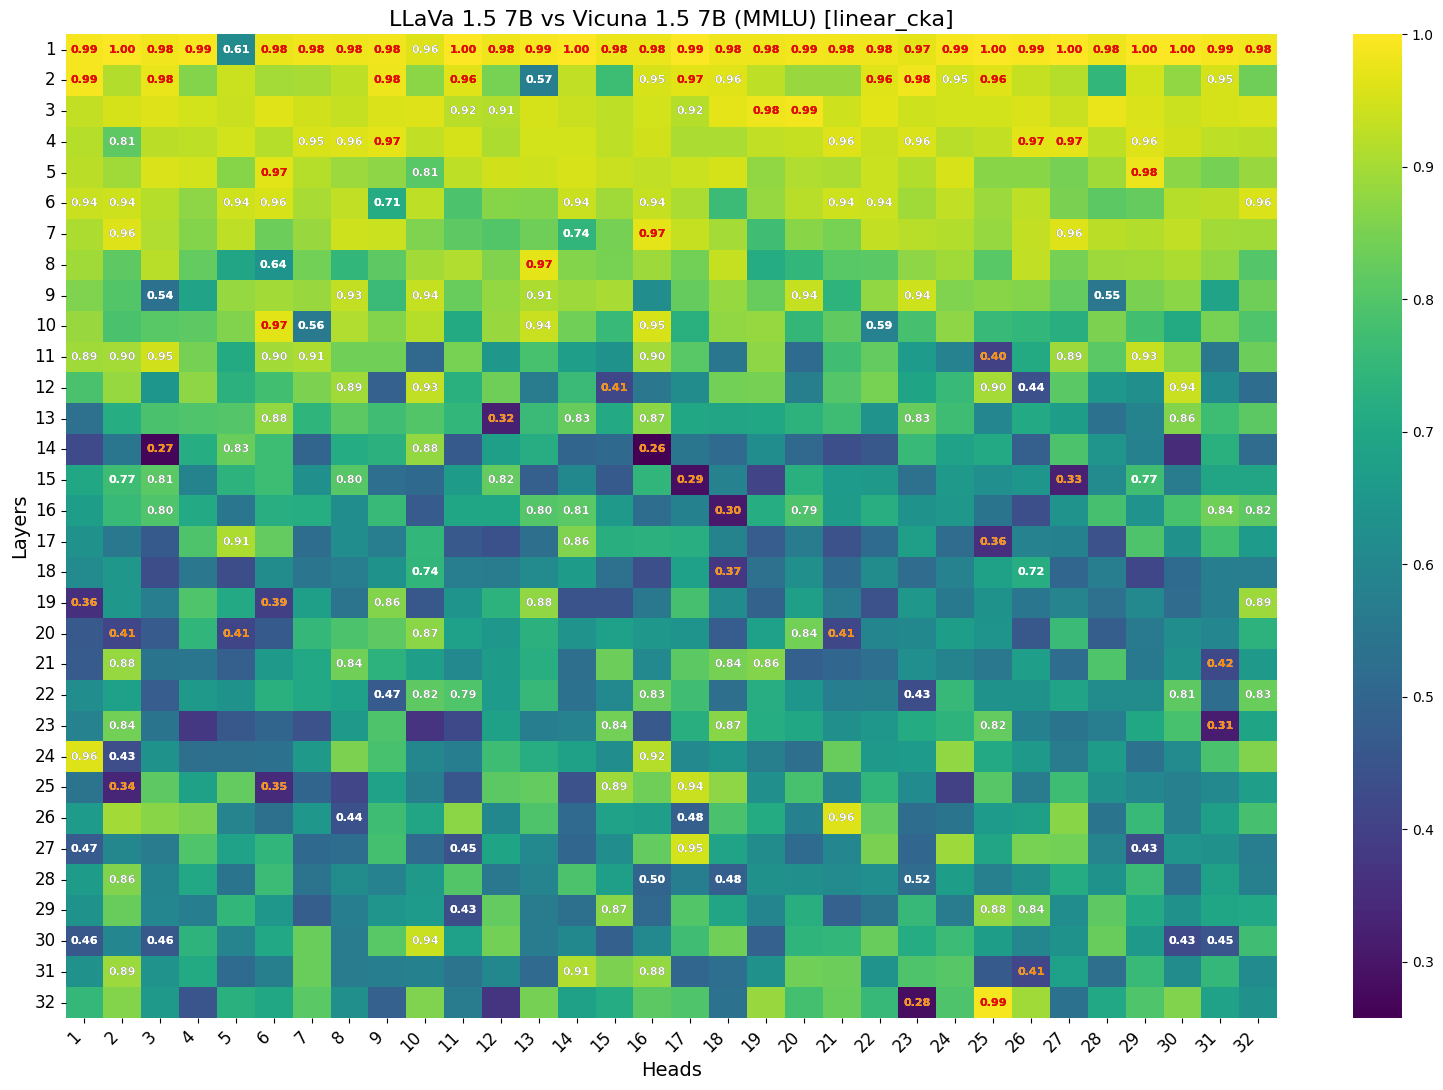

Max linear_cka: 1.00, Min linear_cka: 0.17
Min upper bound: 0.7964, Max lower bound: 0.8762
% in upper bound (white): 15.53%, # values: 159
% in lower bound (white): 5.86%, # values: 60
% in bounds (white): 21.39%, # values: 219
Top 5.00% cutoff value: 0.9639
% identified as top p%: 5.08%, # values: 52
Bottom 3.00% cutoff value: 0.4513
% identified as bottom p%: 3.03%, # values: 31
% in top p% (red): 4.88%, # values: 50
% in bottom p% (orange): 2.15%, # values: 22
% in top and bottom p% (red and orange): 7.03%, # values: 72


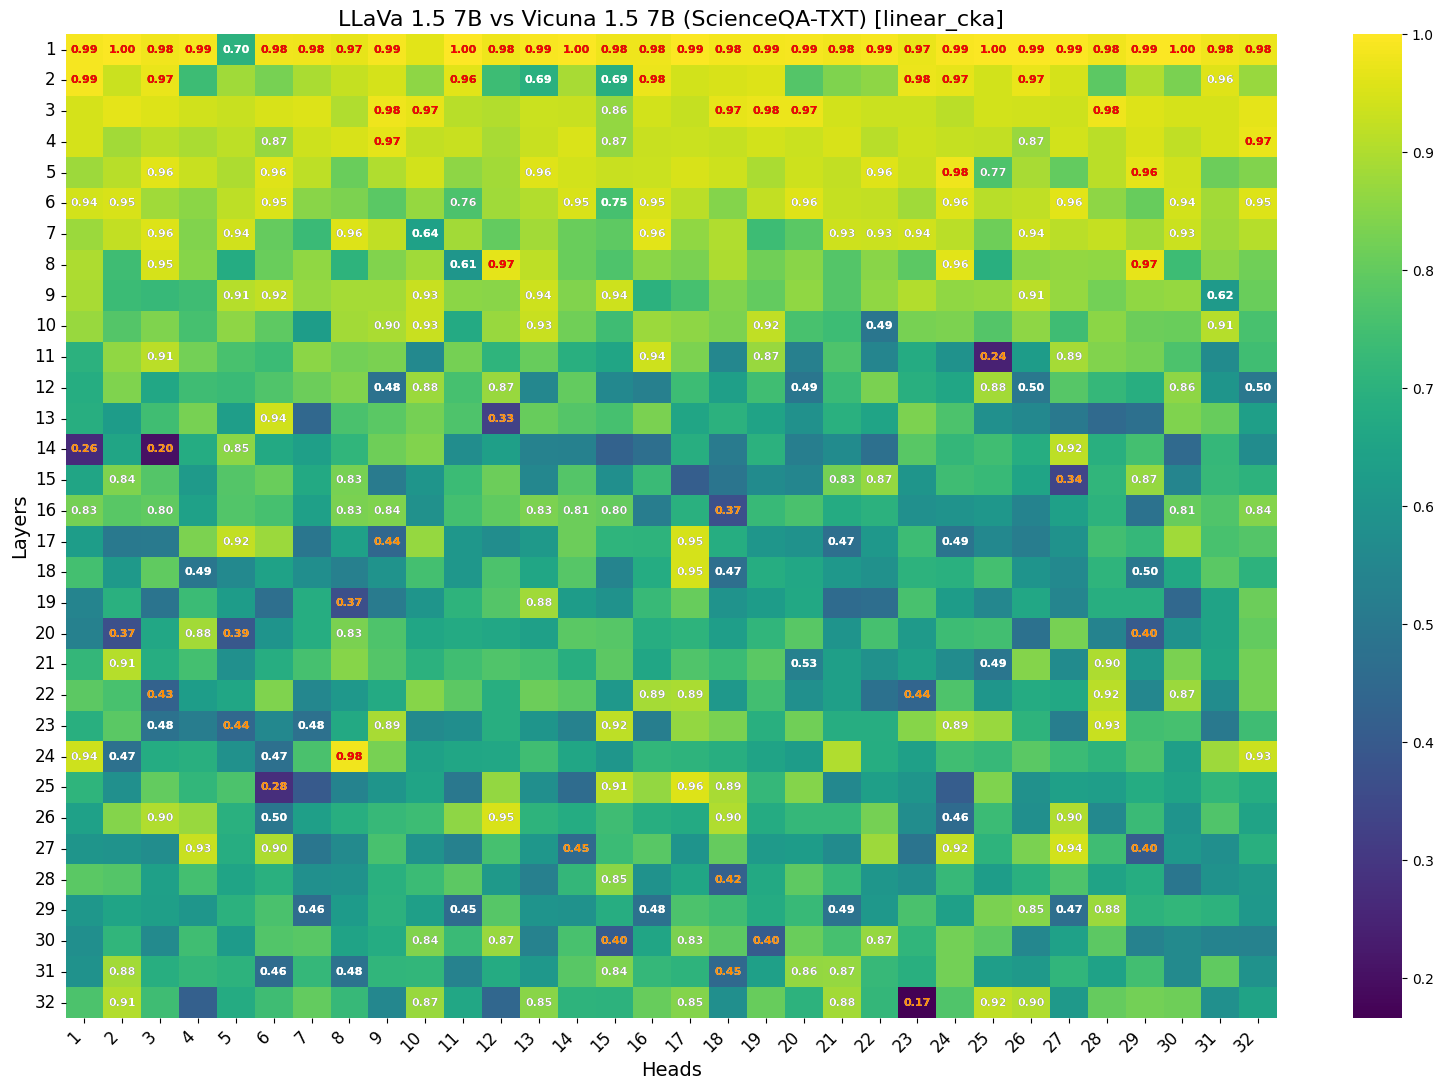

Max linear_cka: 0.99, Min linear_cka: 0.06
Min upper bound: 0.6016, Max lower bound: 0.8257
% in upper bound (white): 9.86%, # values: 101
% in lower bound (white): 7.71%, # values: 79
% in bounds (white): 17.58%, # values: 180
Top 5.00% cutoff value: 0.8745
% identified as top p%: 5.08%, # values: 52
Bottom 3.00% cutoff value: 0.1586
% identified as bottom p%: 3.03%, # values: 31
% in top p% (red): 2.44%, # values: 25
% in bottom p% (orange): 2.93%, # values: 30
% in top and bottom p% (red and orange): 5.37%, # values: 55


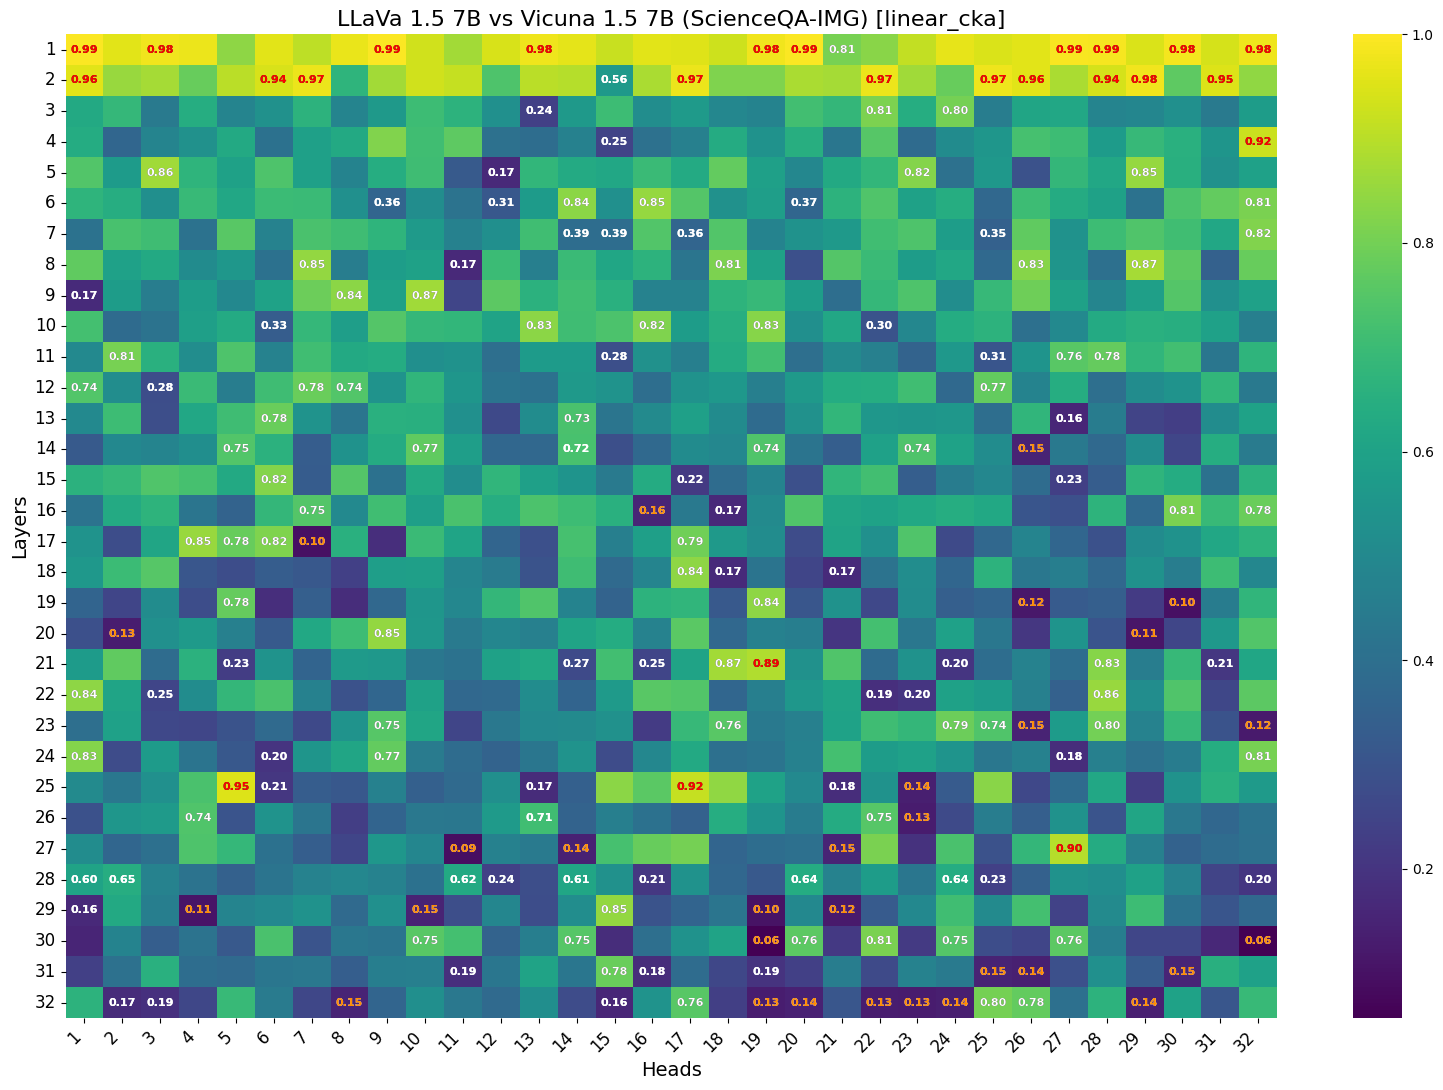

Max linear_cka: 0.73, Min linear_cka: -0.28
Min upper bound: 0.1447, Max lower bound: 0.1672
% in upper bound (white): 6.35%, # values: 65
% in lower bound (white): 7.52%, # values: 77
% in bounds (white): 13.87%, # values: 142
Top 5.00% cutoff value: 0.4852
% identified as top p%: 5.08%, # values: 52
Bottom 3.00% cutoff value: -0.0793
% identified as bottom p%: 3.03%, # values: 31
% in top p% (red): 2.44%, # values: 25
% in bottom p% (orange): 2.15%, # values: 22
% in top and bottom p% (red and orange): 4.59%, # values: 47


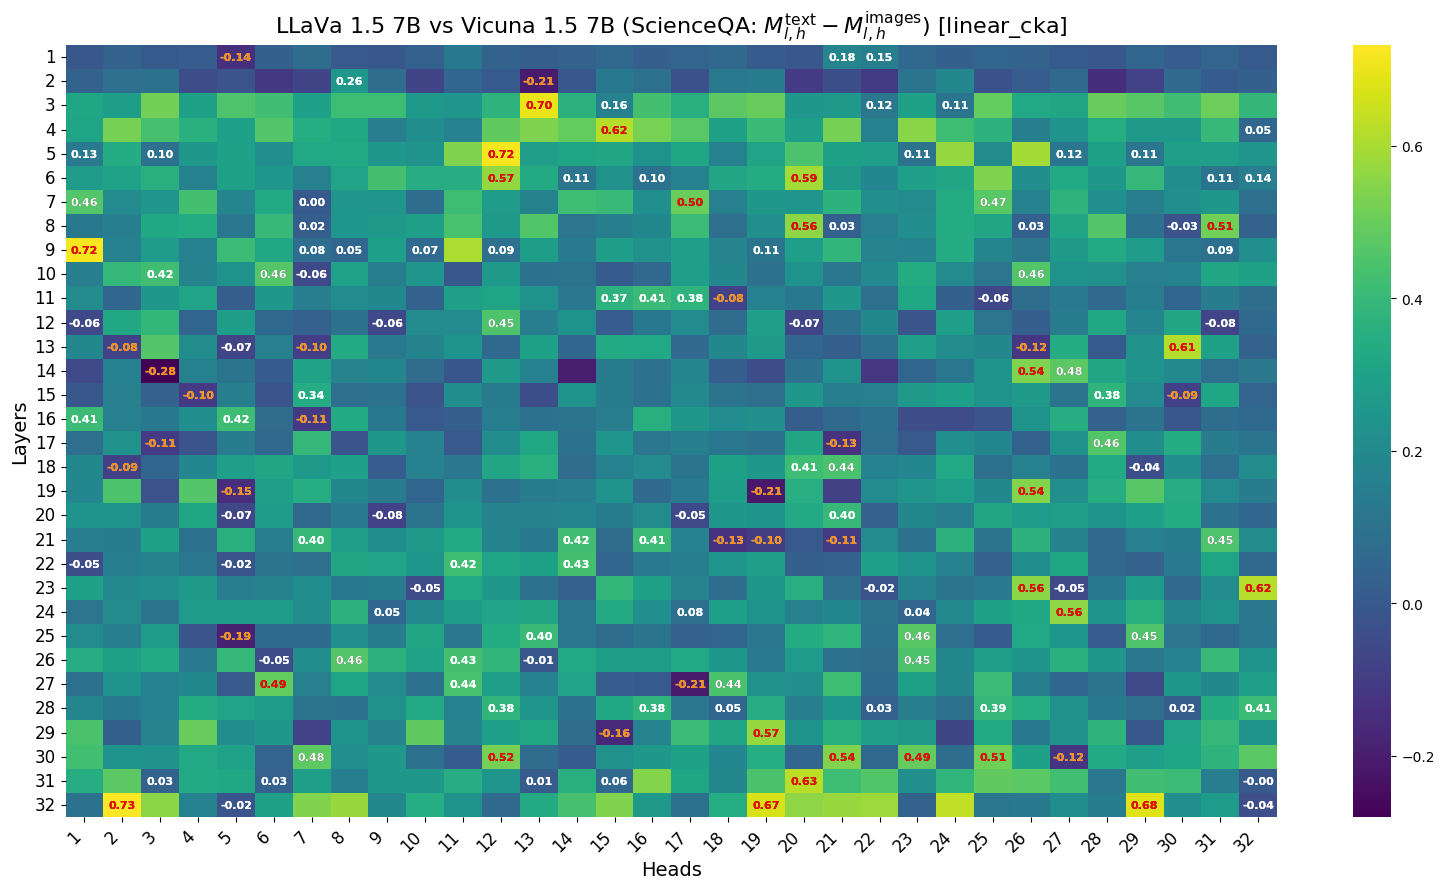

Max linear_cka: 0.96, Min linear_cka: 0.03
Min upper bound: 0.3907, Max lower bound: 0.7355
% in upper bound (white): 8.11%, # values: 83
% in lower bound (white): 9.47%, # values: 97
% in bounds (white): 17.58%, # values: 180
Top 5.00% cutoff value: 0.8626
% identified as top p%: 5.08%, # values: 52
Bottom 3.00% cutoff value: 0.0907
% identified as bottom p%: 3.03%, # values: 31
% in top p% (red): 2.34%, # values: 24
% in bottom p% (orange): 2.83%, # values: 29
% in top and bottom p% (red and orange): 5.18%, # values: 53


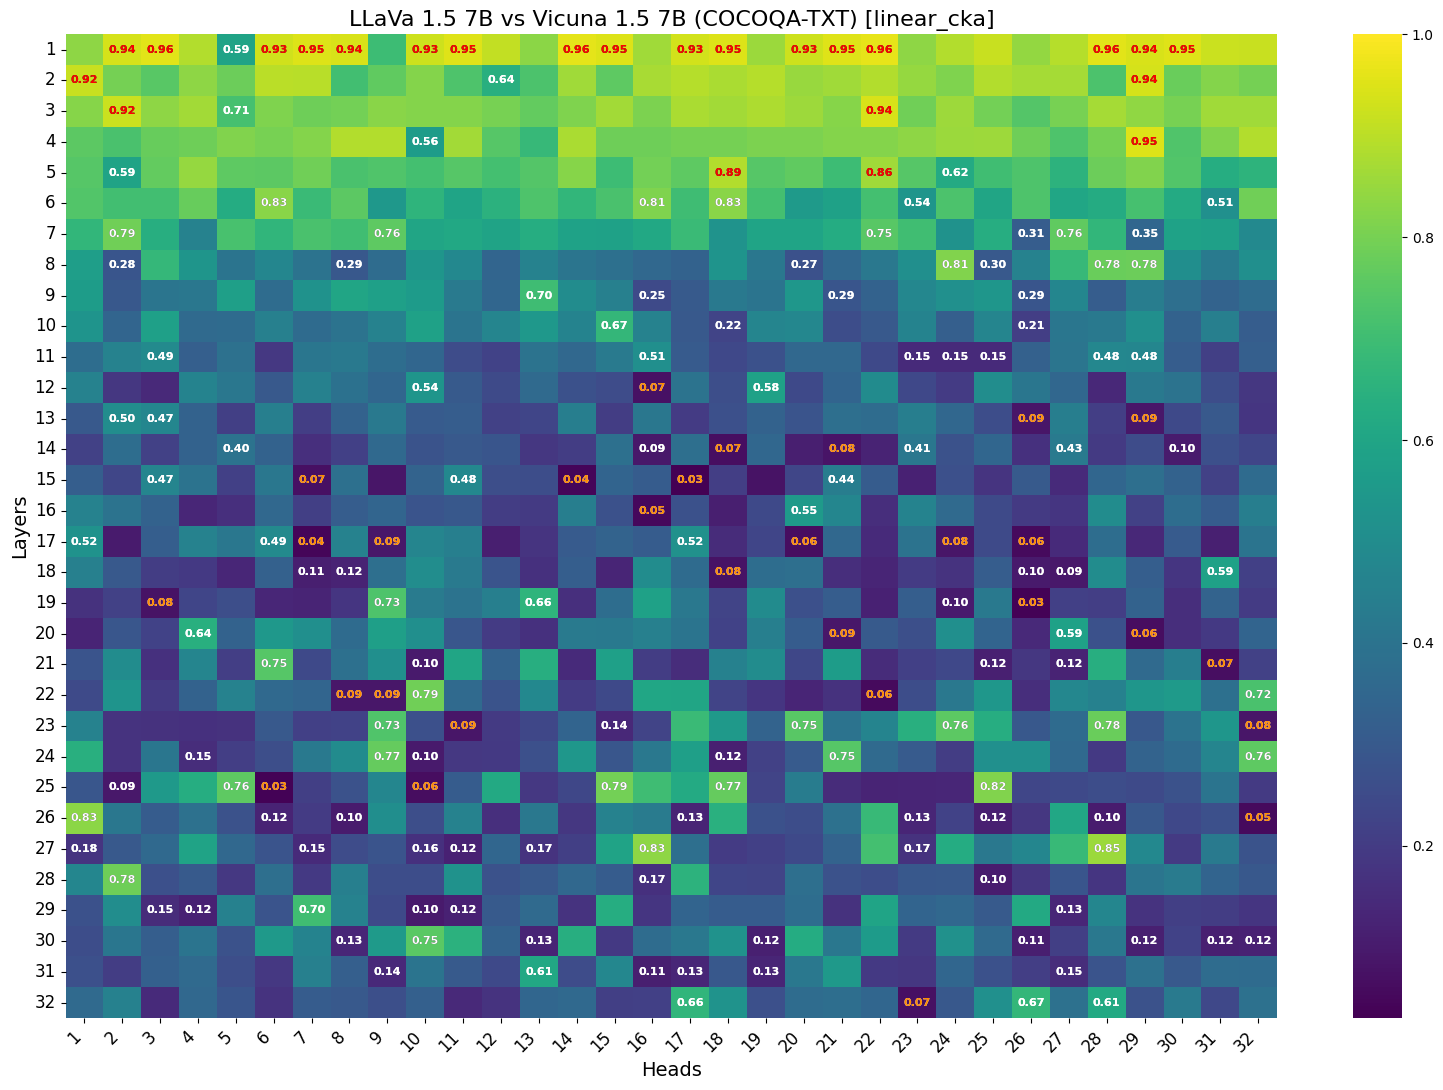

Max linear_cka: 0.99, Min linear_cka: 0.01
Min upper bound: 0.2683, Max lower bound: 0.6881
% in upper bound (white): 6.64%, # values: 68
% in lower bound (white): 17.68%, # values: 181
% in bounds (white): 24.32%, # values: 249
Top 5.00% cutoff value: 0.7692
% identified as top p%: 5.08%, # values: 52
Bottom 3.00% cutoff value: 0.0286
% identified as bottom p%: 3.03%, # values: 31
% in top p% (red): 2.25%, # values: 23
% in bottom p% (orange): 3.03%, # values: 31
% in top and bottom p% (red and orange): 5.27%, # values: 54


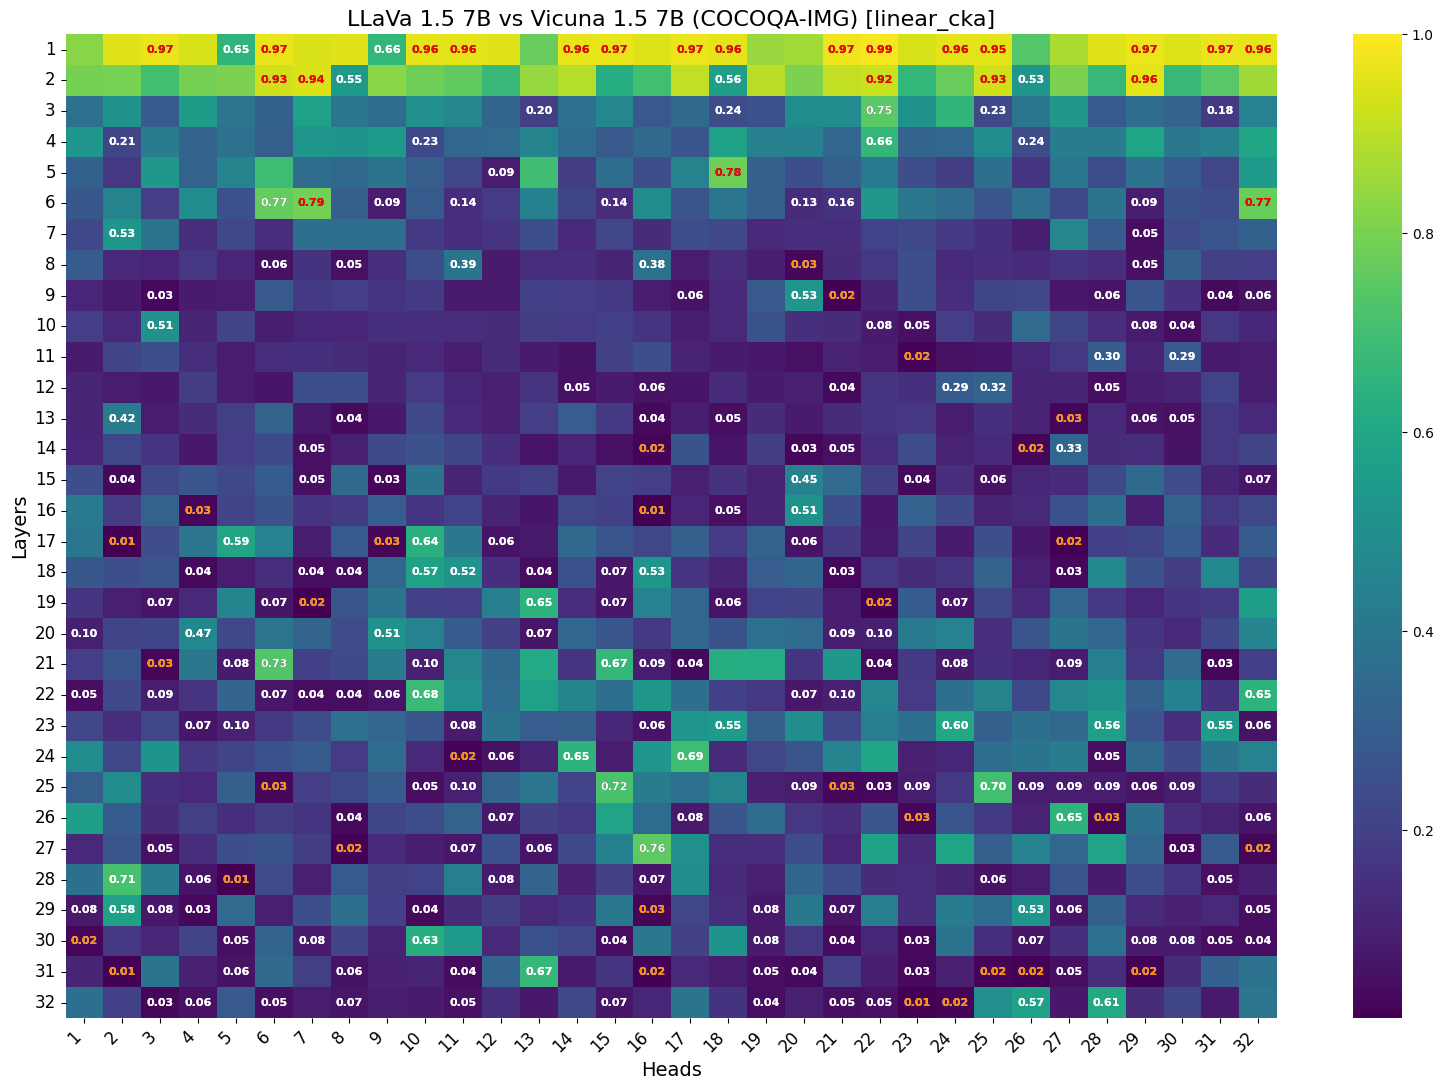

Max linear_cka: 0.73, Min linear_cka: -0.41
Min upper bound: 0.0834, Max lower bound: 0.2452
% in upper bound (white): 6.64%, # values: 68
% in lower bound (white): 5.76%, # values: 59
% in bounds (white): 12.40%, # values: 127
Top 5.00% cutoff value: 0.4750
% identified as top p%: 5.08%, # values: 52
Bottom 3.00% cutoff value: -0.1043
% identified as bottom p%: 3.03%, # values: 31
% in top p% (red): 1.86%, # values: 19
% in bottom p% (orange): 1.95%, # values: 20
% in top and bottom p% (red and orange): 3.81%, # values: 39


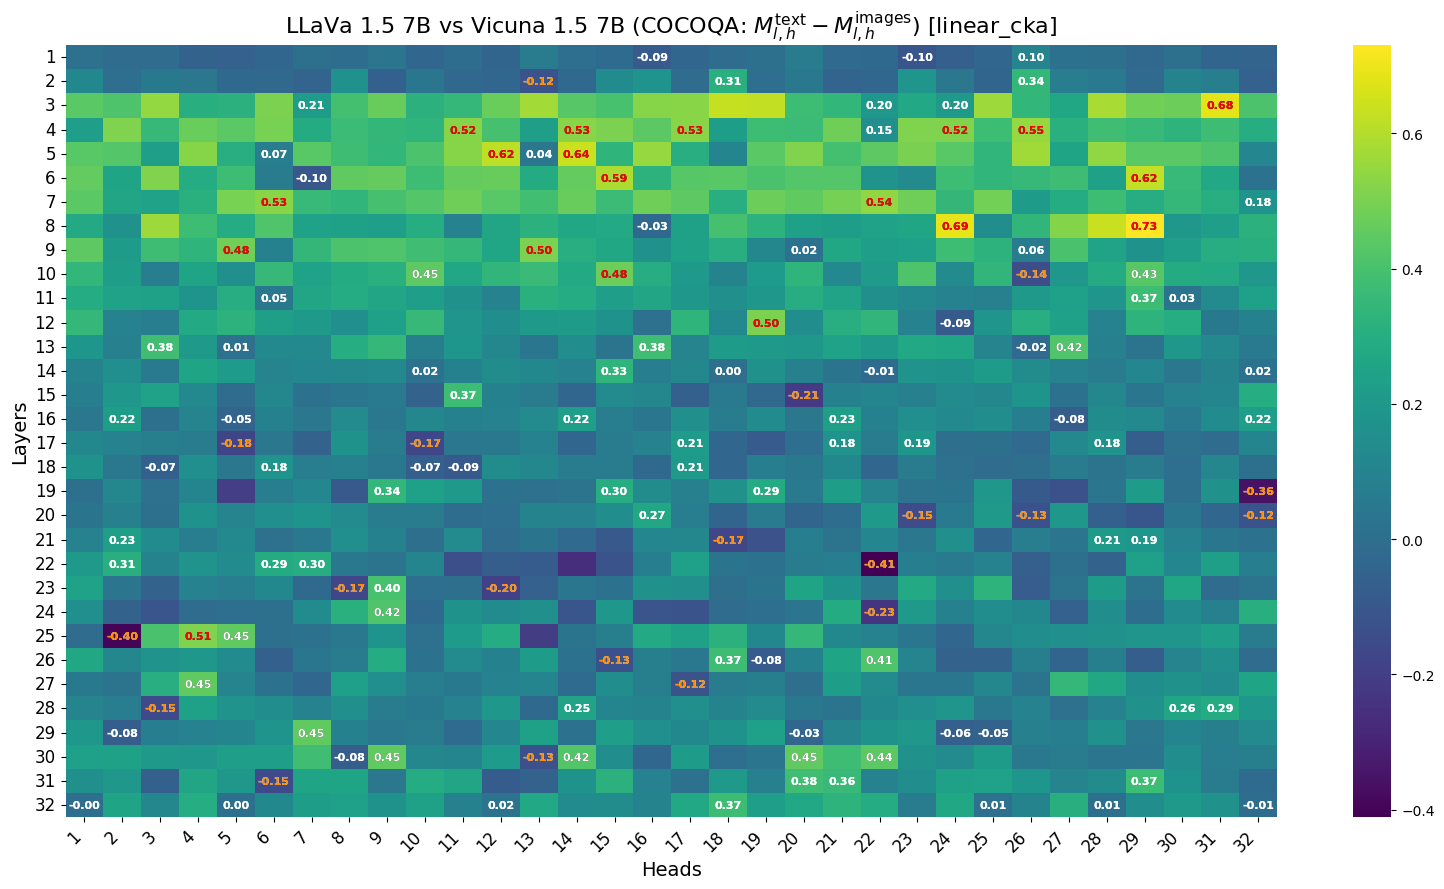

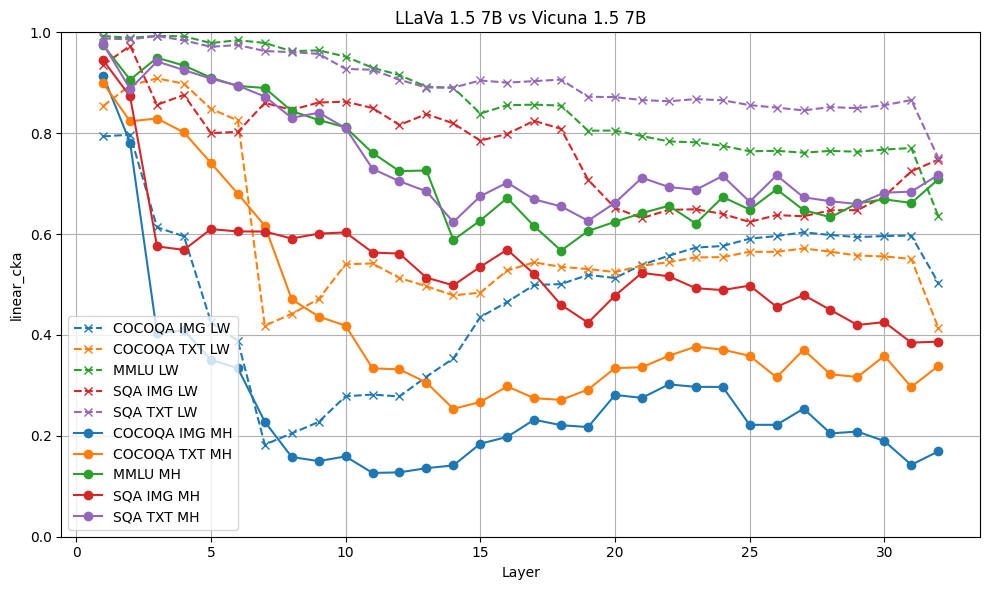

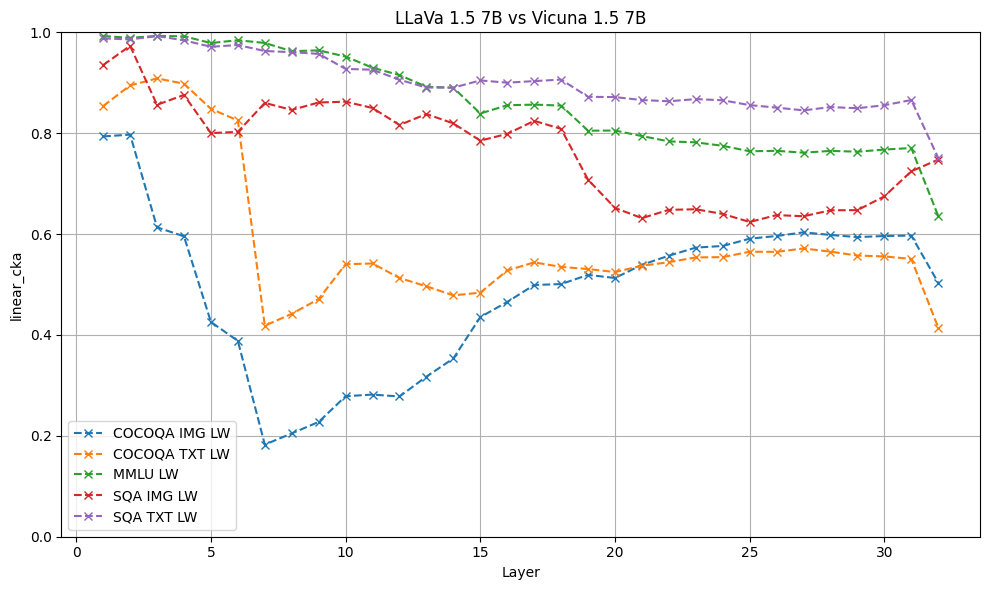

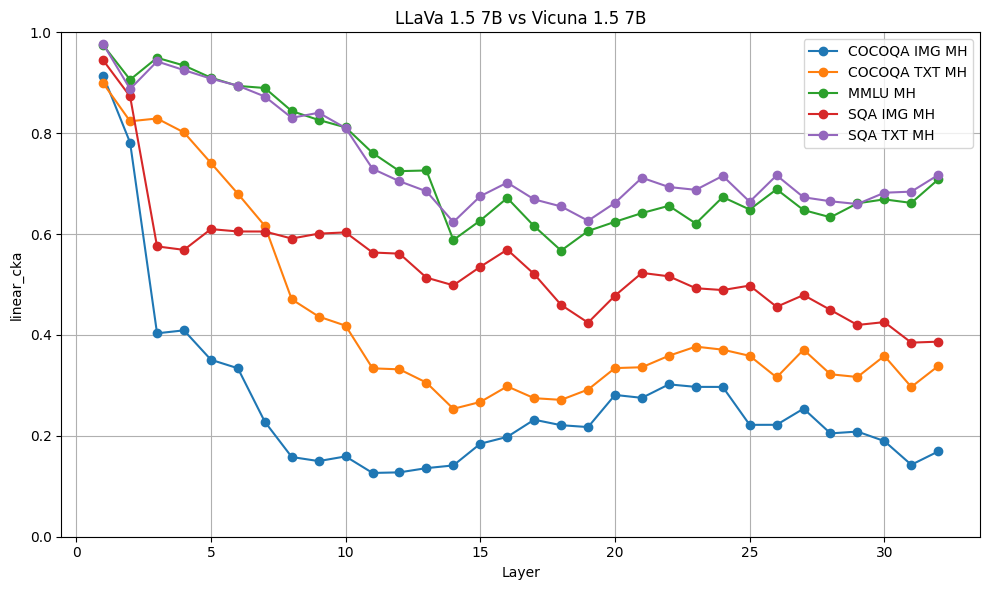

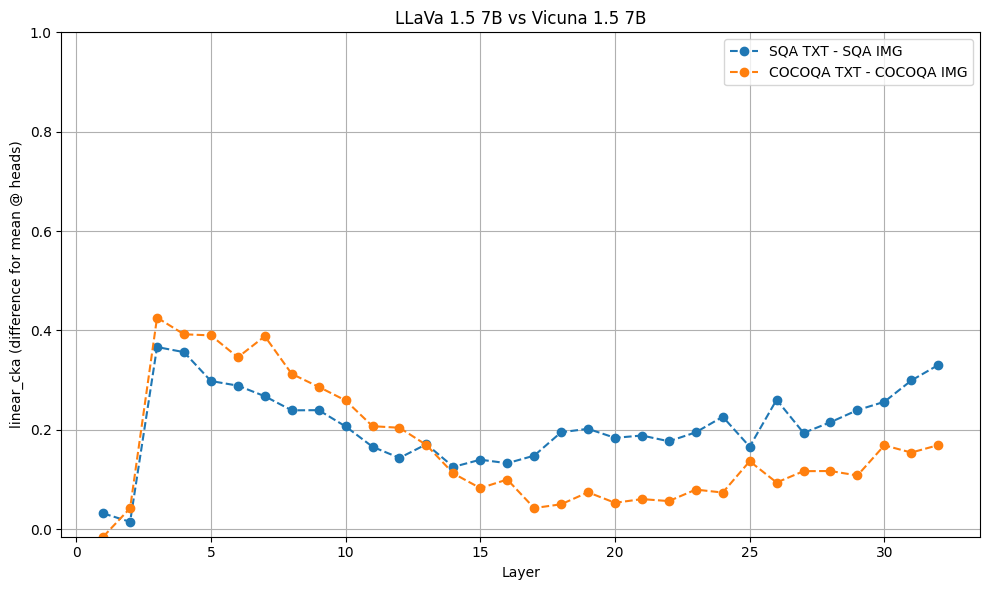

In [45]:
make_plots(
    measure="linear_cka", 
    sim_measure_matrix_cocoimg="cocoqa_captioning_restval_heads_representations_layer-all_token-last_pproj_img-qa_chat_gtxt_cfm_ds2500_s42_batch1_reps-ds2500.parquet",
    sim_measure_matrix_cocotxt="cocoqa_captioning_restval_heads_representations_layer-all_token-last_pproj_txt-qa_chat_gtxt_cfm_ds2500_s42_batch1_reps-ds2500.parquet",
    sim_measure_matrix_mmlu="mmlu_test_heads_representations_layer-all_token-last_pproj_txt-qa_chat_qitype-singular_gtxt_cfm_ds2500_s42_batch1_reps-ds2500.parquet",
    sim_measure_matrix_scienceqa_img="ScienceQA_test_heads_representations_layer-all_token-last_pproj_img-qa_chat_qitype-singular_gtxt_cfm_s42_batch1.parquet",
    sim_measure_matrix_scienceqa_txt="ScienceQA_test_heads_representations_layer-all_token-last_pproj_txt-qa_chat_qitype-singular_gtxt_cfm_s42_batch1.parquet",
    sim_measure_layerwise_cocoimg="cocoqa_captioning_restval_layers_representations_layer-all_token-last_pproj_img-qa_chat_gtxt_cfm_ds2500_s42_reps-ds2500.csv",
    sim_measure_layerwise_cocotxt="cocoqa_captioning_restval_layers_representations_layer-all_token-last_pproj_txt-qa_chat_gtxt_cfm_ds2500_s42_reps-ds2500.csv",
    sim_measure_layerwise_mmlu="mmlu_test_layers_representations_layer-all_token-last_pproj_txt-qa_chat_qitype-singular_gtxt_cfm_ds2500_s42_reps-ds2500.csv",
    sim_measure_layerwise_scienceqa_img="ScienceQA_test_layers_representations_layer-all_token-last_pproj_img-qa_chat_qitype-singular_gtxt_cfm_s42.csv",
    sim_measure_layerwise_scienceqa_txt="ScienceQA_test_layers_representations_layer-all_token-last_pproj_txt-qa_chat_qitype-singular_gtxt_cfm_s42.csv",
)

Max svcca: 0.99, Min svcca: 0.49
Min upper bound: 0.8236, Max lower bound: 0.9664
% in upper bound (white): 11.33%, # values: 116
% in lower bound (white): 6.45%, # values: 66
% in bounds (white): 17.77%, # values: 182
Top 5.00% cutoff value: 0.9512
% identified as top p%: 5.08%, # values: 52
Bottom 3.00% cutoff value: 0.7069
% identified as bottom p%: 3.03%, # values: 31
% in top p% (red): 1.27%, # values: 13
% in bottom p% (orange): 1.76%, # values: 18
% in top and bottom p% (red and orange): 3.03%, # values: 31


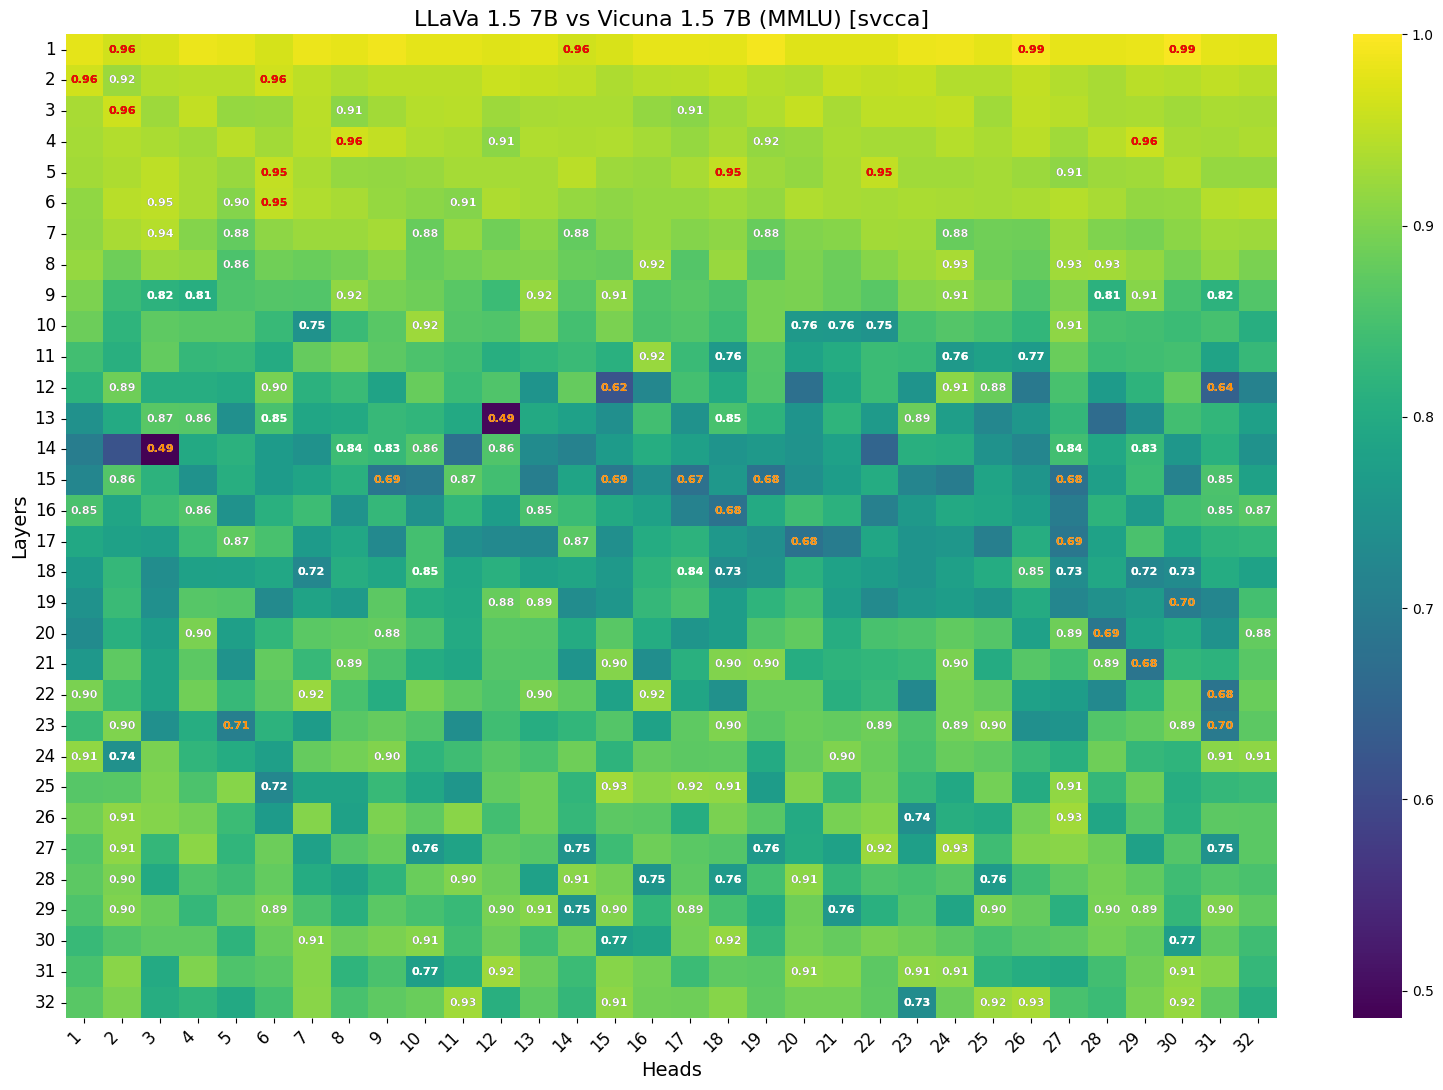

Max svcca: 1.00, Min svcca: 0.60
Min upper bound: 0.8166, Max lower bound: 0.9667
% in upper bound (white): 9.18%, # values: 94
% in lower bound (white): 6.64%, # values: 68
% in bounds (white): 15.82%, # values: 162
Top 5.00% cutoff value: 0.9527
% identified as top p%: 5.08%, # values: 52
Bottom 3.00% cutoff value: 0.7232
% identified as bottom p%: 3.03%, # values: 31
% in top p% (red): 0.88%, # values: 9
% in bottom p% (orange): 1.95%, # values: 20
% in top and bottom p% (red and orange): 2.83%, # values: 29


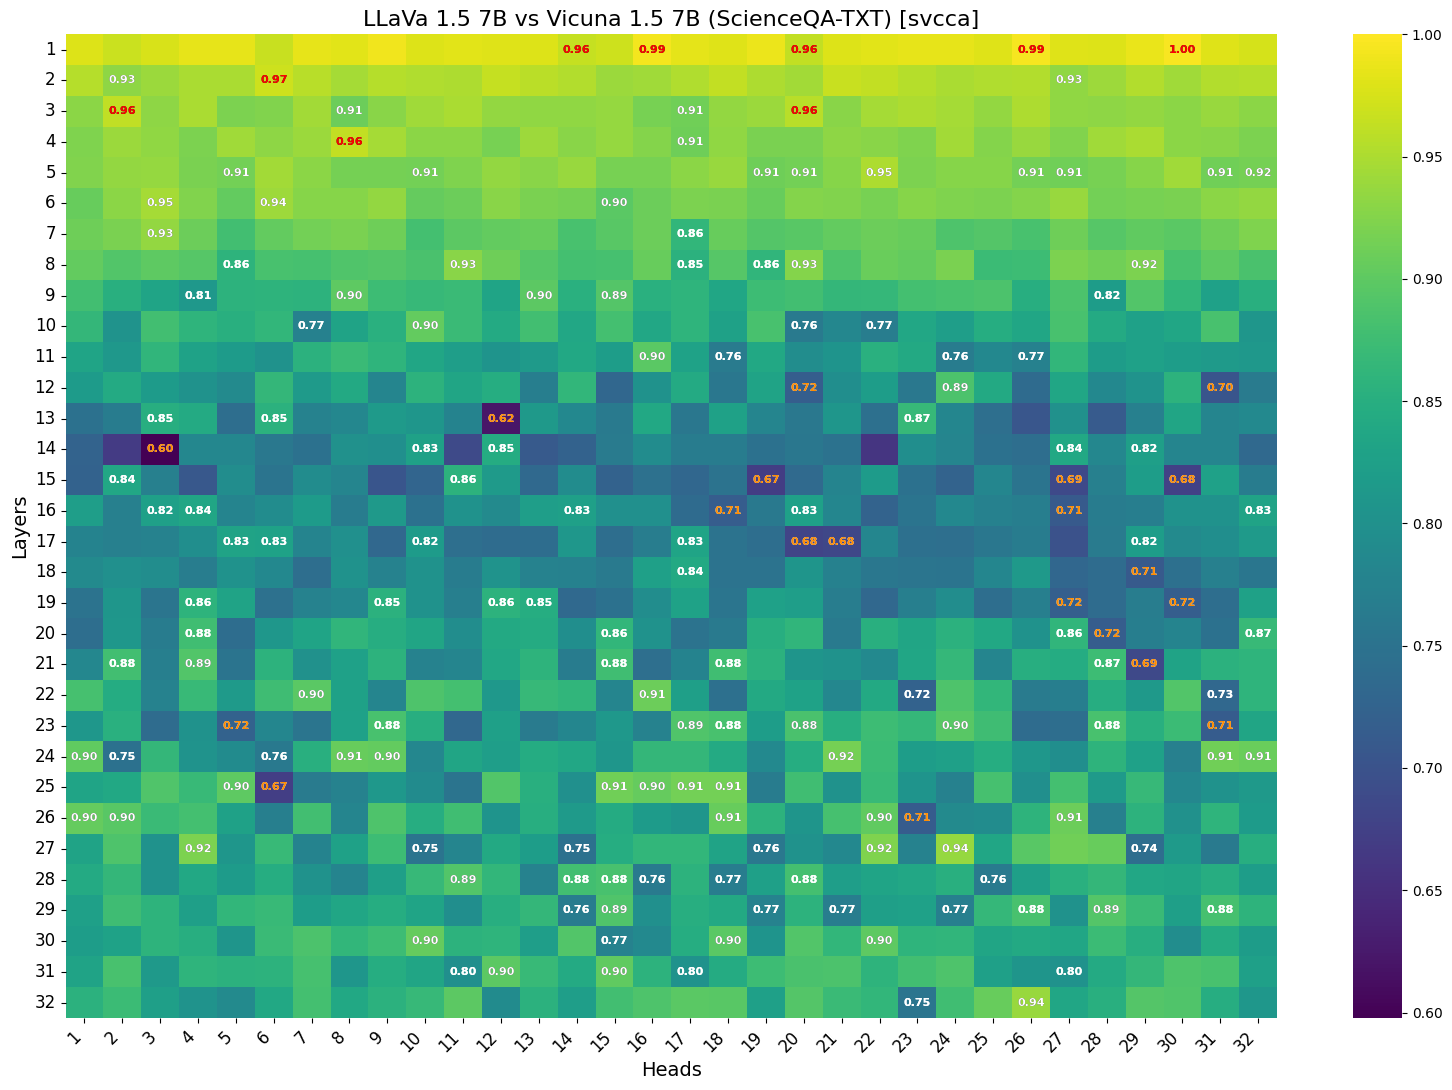

Max svcca: 0.99, Min svcca: 0.48
Min upper bound: 0.6452, Max lower bound: 0.9643
% in upper bound (white): 8.59%, # values: 88
% in lower bound (white): 6.35%, # values: 65
% in bounds (white): 14.94%, # values: 153
Top 5.00% cutoff value: 0.9123
% identified as top p%: 5.08%, # values: 52
Bottom 3.00% cutoff value: 0.5376
% identified as bottom p%: 3.03%, # values: 31
% in top p% (red): 0.78%, # values: 8
% in bottom p% (orange): 2.73%, # values: 28
% in top and bottom p% (red and orange): 3.52%, # values: 36


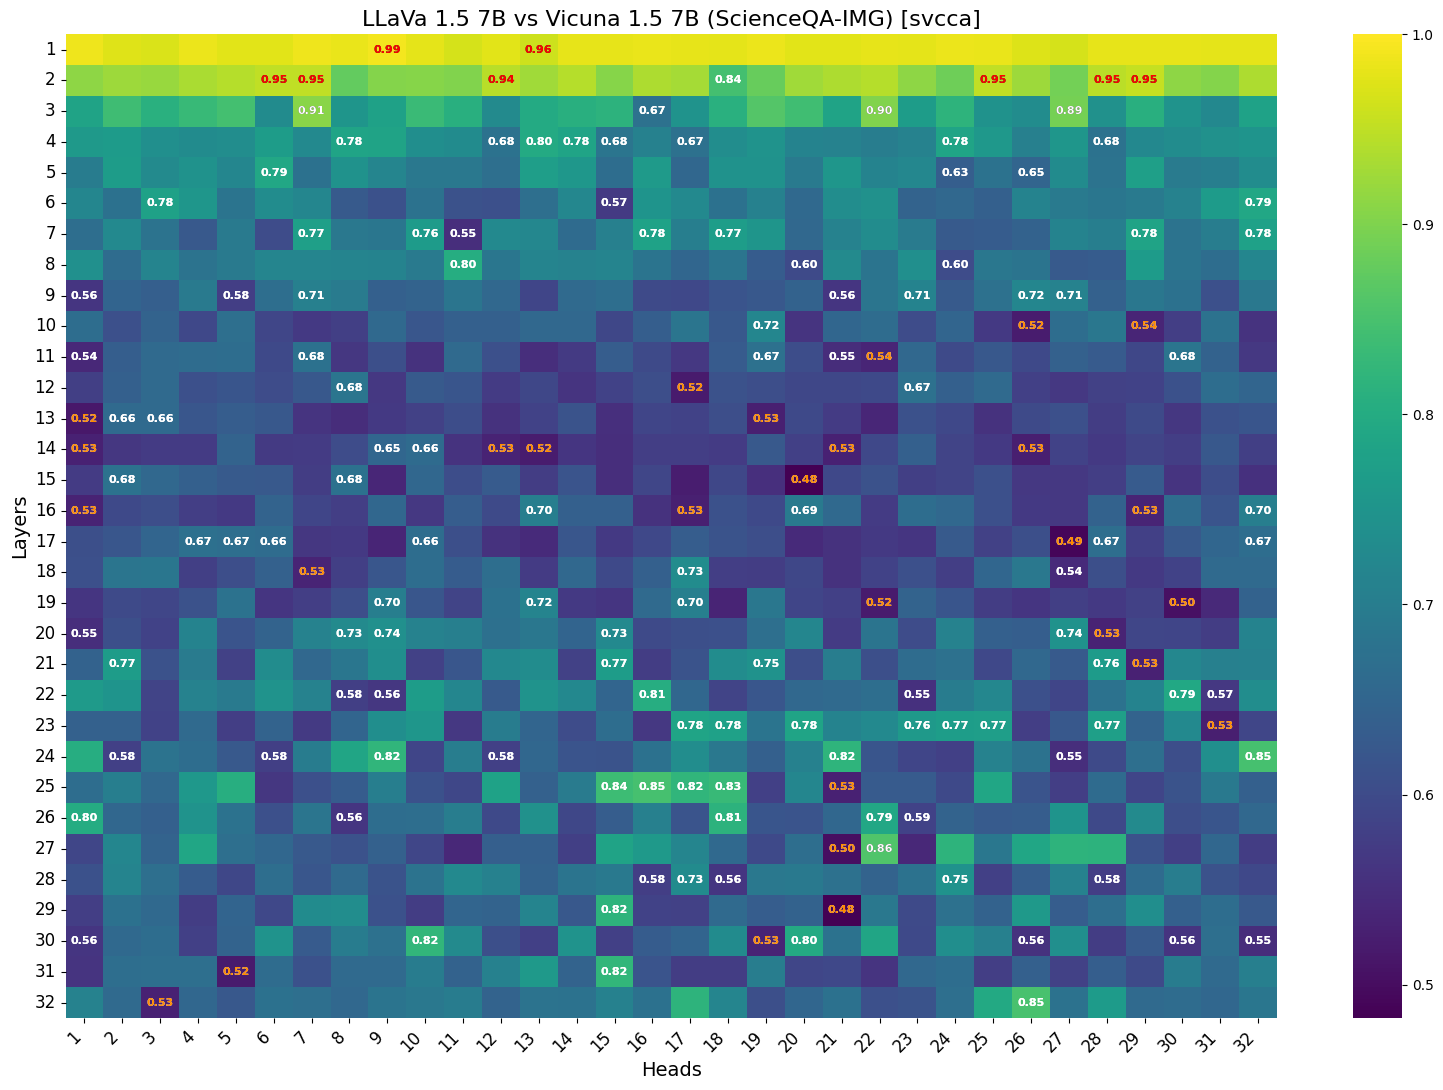

Max svcca: 0.35, Min svcca: -0.02
Min upper bound: 0.0177, Max lower bound: 0.1675
% in upper bound (white): 5.86%, # values: 60
% in lower bound (white): 7.81%, # values: 80
% in bounds (white): 13.67%, # values: 140
Top 5.00% cutoff value: 0.2716
% identified as top p%: 5.08%, # values: 52
Bottom 3.00% cutoff value: 0.0074
% identified as bottom p%: 3.03%, # values: 31
% in top p% (red): 2.73%, # values: 28
% in bottom p% (orange): 0.59%, # values: 6
% in top and bottom p% (red and orange): 3.32%, # values: 34


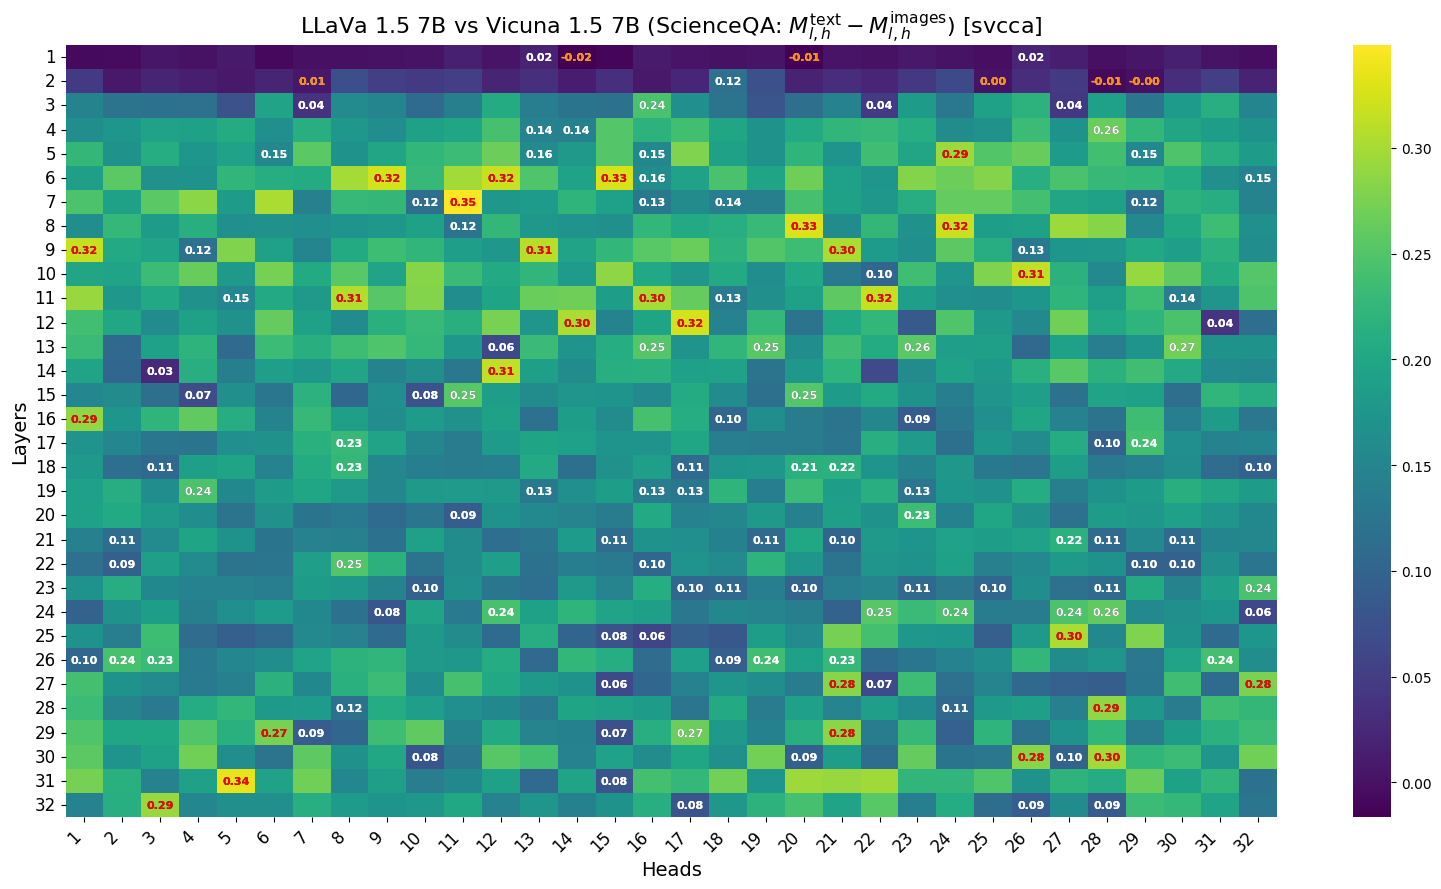

Max svcca: 0.98, Min svcca: 0.26
Min upper bound: 0.5512, Max lower bound: 0.8990
% in upper bound (white): 9.28%, # values: 95
% in lower bound (white): 6.45%, # values: 66
% in bounds (white): 15.72%, # values: 161
Top 5.00% cutoff value: 0.9225
% identified as top p%: 5.08%, # values: 52
Bottom 3.00% cutoff value: 0.4165
% identified as bottom p%: 3.03%, # values: 31
% in top p% (red): 0.78%, # values: 8
% in bottom p% (orange): 1.37%, # values: 14
% in top and bottom p% (red and orange): 2.15%, # values: 22


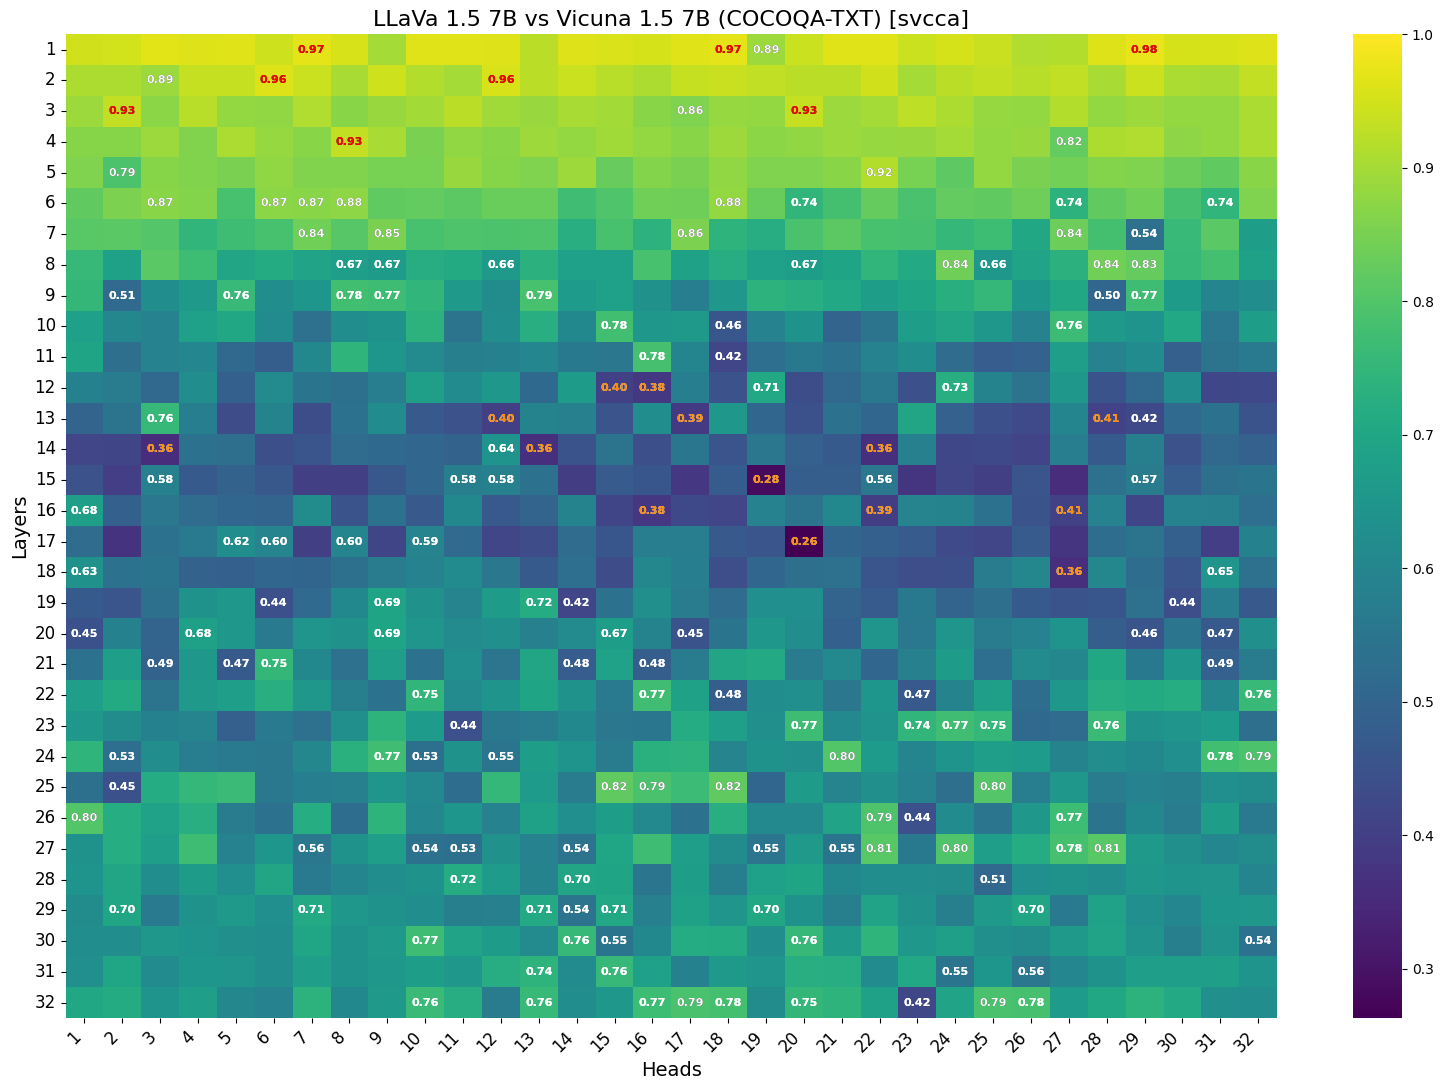

Max svcca: 0.98, Min svcca: 0.26
Min upper bound: 0.4082, Max lower bound: 0.9035
% in upper bound (white): 6.25%, # values: 64
% in lower bound (white): 9.18%, # values: 94
% in bounds (white): 15.43%, # values: 158
Top 5.00% cutoff value: 0.8962
% identified as top p%: 5.08%, # values: 52
Bottom 3.00% cutoff value: 0.2993
% identified as bottom p%: 3.03%, # values: 31
% in top p% (red): 2.25%, # values: 23
% in bottom p% (orange): 2.05%, # values: 21
% in top and bottom p% (red and orange): 4.30%, # values: 44


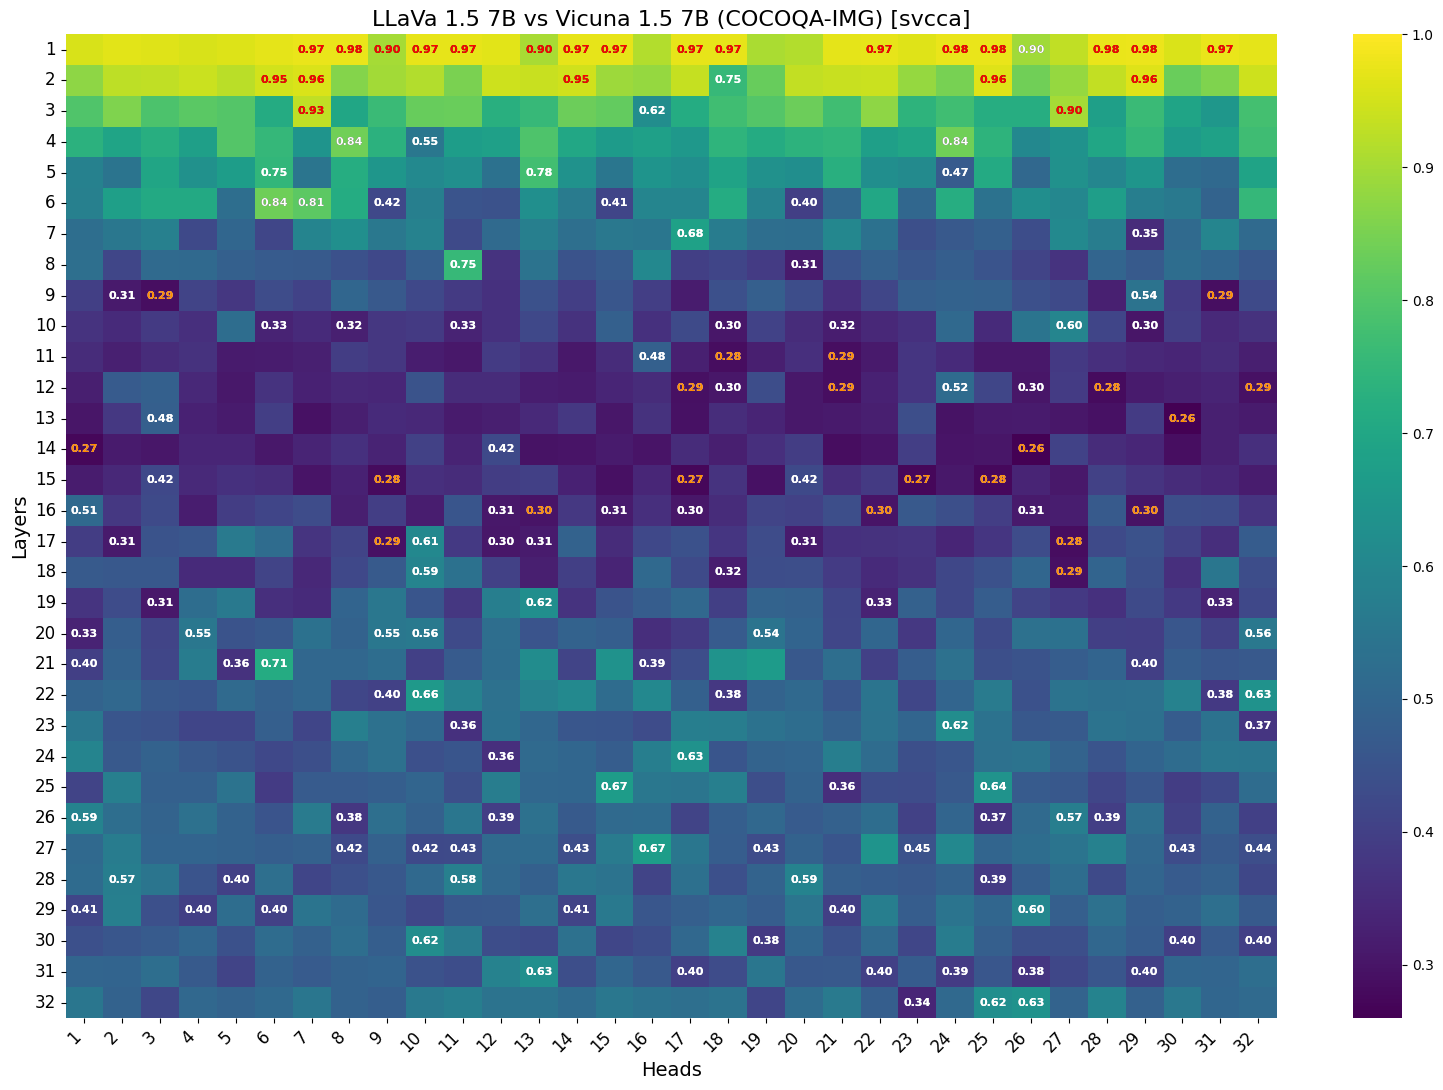

Max svcca: 0.40, Min svcca: -0.13
Min upper bound: 0.0300, Max lower bound: 0.2001
% in upper bound (white): 6.84%, # values: 70
% in lower bound (white): 5.86%, # values: 60
% in bounds (white): 12.70%, # values: 130
Top 5.00% cutoff value: 0.2932
% identified as top p%: 5.08%, # values: 52
Bottom 3.00% cutoff value: -0.0087
% identified as bottom p%: 3.03%, # values: 31
% in top p% (red): 2.15%, # values: 22
% in bottom p% (orange): 1.07%, # values: 11
% in top and bottom p% (red and orange): 3.22%, # values: 33


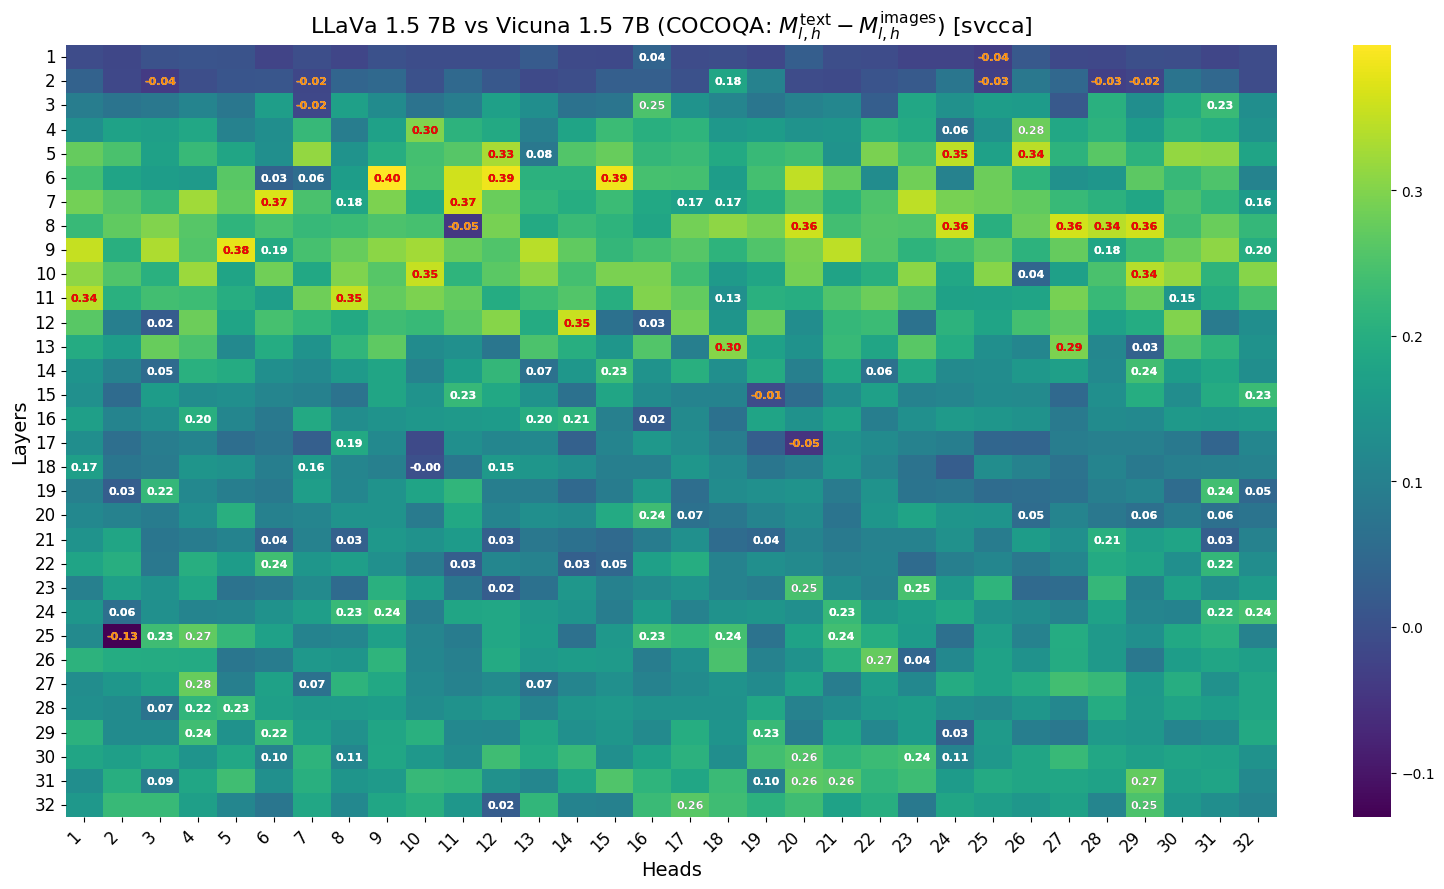

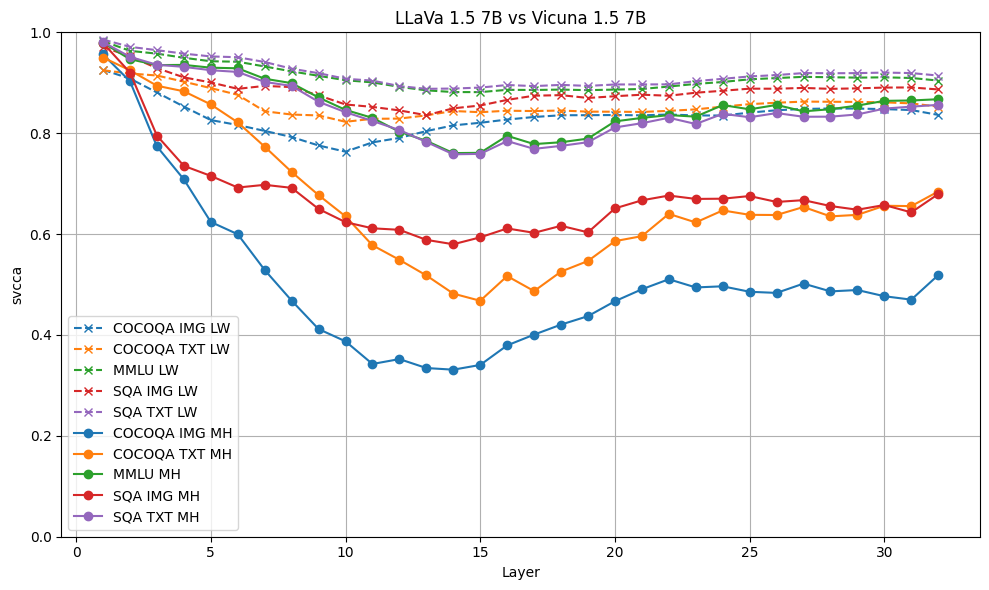

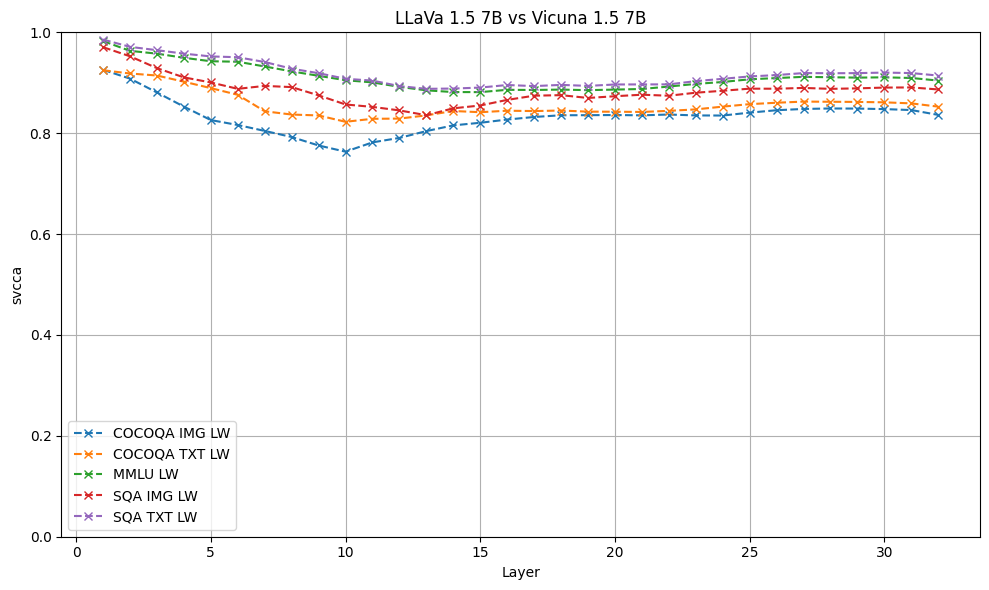

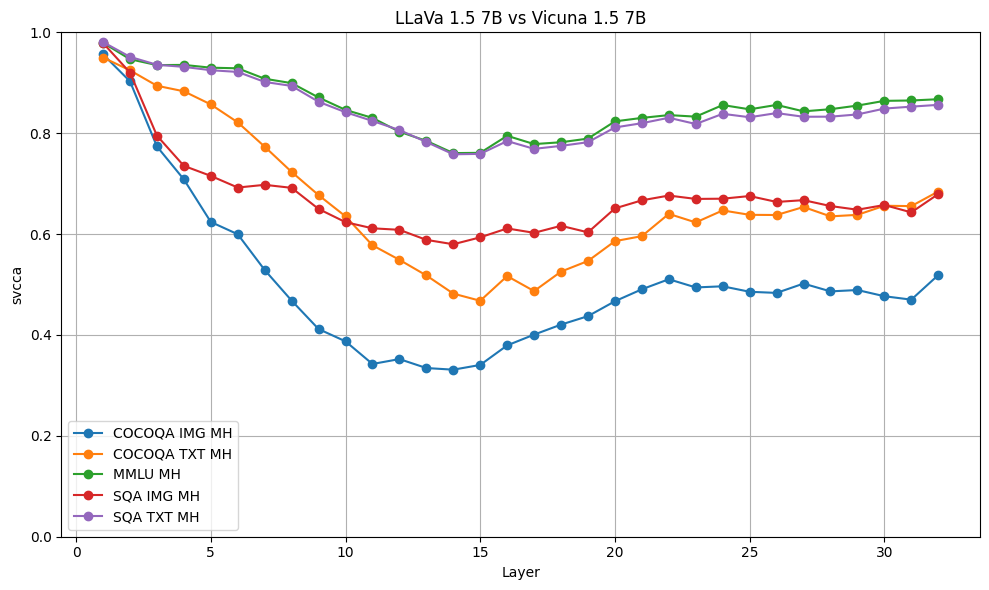

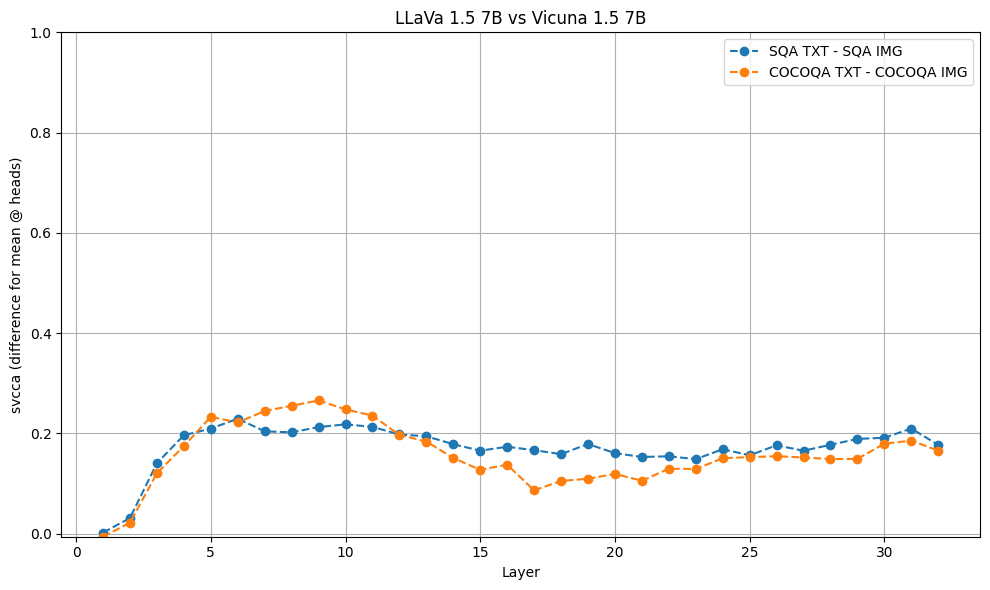

In [46]:
make_plots(
    measure="svcca", 
    sim_measure_matrix_cocoimg="cocoqa_captioning_restval_heads_representations_layer-all_token-last_pproj_img-qa_chat_gtxt_cfm_ds2500_s42_batch1_arate-0.95_reps-ds2500.parquet",
    sim_measure_matrix_cocotxt="cocoqa_captioning_restval_heads_representations_layer-all_token-last_pproj_txt-qa_chat_gtxt_cfm_ds2500_s42_batch1_arate-0.95_reps-ds2500.parquet",
    sim_measure_matrix_mmlu="mmlu_test_heads_representations_layer-all_token-last_pproj_txt-qa_chat_qitype-singular_gtxt_cfm_ds2500_s42_batch1_arate-0.95_reps-ds2500.parquet",
    sim_measure_matrix_scienceqa_img="ScienceQA_test_heads_representations_layer-all_token-last_pproj_img-qa_chat_qitype-singular_gtxt_cfm_s42_batch1_arate-0.95.parquet",
    sim_measure_matrix_scienceqa_txt="ScienceQA_test_heads_representations_layer-all_token-last_pproj_txt-qa_chat_qitype-singular_gtxt_cfm_s42_batch1_arate-0.95.parquet",
    sim_measure_layerwise_cocoimg="cocoqa_captioning_restval_layers_representations_layer-all_token-last_pproj_img-qa_chat_gtxt_cfm_ds2500_s42_arate-0.95_reps-ds2500.csv",
    sim_measure_layerwise_cocotxt="cocoqa_captioning_restval_layers_representations_layer-all_token-last_pproj_txt-qa_chat_gtxt_cfm_ds2500_s42_arate-0.95_reps-ds2500.csv",
    sim_measure_layerwise_mmlu="mmlu_test_layers_representations_layer-all_token-last_pproj_txt-qa_chat_qitype-singular_gtxt_cfm_ds2500_s42_arate-0.95_reps-ds2500.csv",
    sim_measure_layerwise_scienceqa_img="ScienceQA_test_layers_representations_layer-all_token-last_pproj_img-qa_chat_qitype-singular_gtxt_cfm_s42_arate-0.95.csv",
    sim_measure_layerwise_scienceqa_txt="ScienceQA_test_layers_representations_layer-all_token-last_pproj_txt-qa_chat_qitype-singular_gtxt_cfm_s42_arate-0.95.csv",
)

## Removed Code

In [ ]:
import numpy as np
from ipywidgets import interact, FloatSlider, Dropdown
from IPython.display import clear_output


def binary_op(A_bin, B_bin, operation):
    if operation == "xor":
        return np.logical_xor(A_bin, B_bin).astype(int)
    elif operation == "or":
        return np.logical_or(A_bin, B_bin).astype(int)
    elif operation == "and":
        return np.logical_and(A_bin, B_bin).astype(int)
    else:
        raise ValueError(f"Unknown operation '{operation}'")


def visualize_matrix(A, B, threshold, operation):
    clear_output(wait=True)  # This clears previous output in the cell
    A_bin = A > threshold
    B_bin = B > threshold
    result = binary_op(A_bin, B_bin, operation)

    plt.figure(figsize=(5, 5))
    plt.imshow(result, cmap="gray", vmin=0, vmax=1)
    plt.title(
        rf"${{{operation.upper()}}}: M^{{\text{{text}}}}_{{\geq \tau}} \oplus M^{{\text{{images}}}}_{{\geq \tau}},\ \tau = {threshold:.2f}$"
    )
    plt.axis("off")
    plt.show()


# Dropdown for operation and slider for threshold
def binary_heads_change(A, B):
    interact(
        lambda t, op: visualize_matrix(A, B, t, op),
        t=FloatSlider(min=0, max=1, step=0.01, value=0.5, description="Threshold"),
        op=Dropdown(options=["xor", "or", "and"], value="xor", description="Operation"),
    )


def visualize_matrix_subplot(ax, A, B, threshold, operation):
    A_bin = A >= threshold
    B_bin = B <= threshold
    result = binary_op(A_bin, B_bin, operation)

    ax.imshow(result, cmap="gray", vmin=0, vmax=1)
    ax.set_title(rf"$\tau = {threshold:.2f}$", fontsize=10)
    ax.axis("off")


# Main plotting code
def plot_all_thresholds(A, B, thresholds, operation, rows=4, cols=3):
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3))
    axes = axes.flatten()  # Flatten in case it's 2D

    for i, threshold in enumerate(thresholds):
        if i < len(axes):
            visualize_matrix_subplot(axes[i], A, B, threshold, operation)

    # Hide any unused axes (if thresholds < rows * cols)
    for j in range(len(thresholds), len(axes)):
        axes[j].axis("off")

    fig.suptitle(
        rf"${operation.upper()}: M^{{\text{{text}}}}_{{\geq \tau}} \oplus M^{{\text{{images}}}}_{{\geq \tau}}$",
        fontsize=16,
    )

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])  # Leave space for suptitle
    plt.show()


def plot_box_plot_layerwise_stats_across_heads(
    df,
    dataset_name="Dataset",
):
    """
    Plots a box plot of layerwise statistics across heads.
    Parameters:
    - df: pandas DataFrame with index like L0, L1, ..., L31 and columns like 'mean', 'std', 'min', etc.
    """

    # Transpose the DataFrame so that rows become columns for plotting
    plt.boxplot(df.T, vert=False)
    plt.yticks(
        ticks=range(1, len(df) + 1),
        labels=df.index,
    )
    plt.xlim(0, 1)
    plt.xlabel("Neighborhood Overlap (LLaVa 1.5 7b vs Vicuna 1.5 7B)")
    plt.ylabel("Layer Index")
    plt.title(f"Layerwise Statistics of Heads Representations ({dataset_name})")
    plt.show()


def plot_overlap_heads_moments_vs_layerwise(
    overlap_heads_moments_df,
    layerwise_overlap_df,
    figsize=(12, 6),
    dataset_name="Dataset",
):
    """
    Plots selected row-wise statistics against layer index.

    Parameters:
    - overlap_heads_moments_df: pandas DataFrame with index like L0, L1, ..., L31 and columns like 'mean', 'std', 'min', etc.
    - layerwise_overlap_df: pandas DataFrame with layerwise overlap statistics
    - figsize: tuple, size of the figure
    - title: plot title
    """

    x = overlap_heads_moments_df.index.to_numpy()
    mean = overlap_heads_moments_df["mean"].to_numpy()
    std = overlap_heads_moments_df["std"].to_numpy()
    upper = mean + std
    lower = mean - std

    stats_to_plot = overlap_heads_moments_df.columns.difference(["mean", "std"])

    # Plot
    plt.figure(figsize=figsize)
    for stat in stats_to_plot:
        plt.plot(overlap_heads_moments_df[stat], marker="o", label=stat)

    # Plot mean and std as band
    plt.plot(x, mean, marker="o", label="Mean", linewidth=2)
    plt.fill_between(x, lower, upper, alpha=0.2, label="±1 Std Dev")

    # Plot layerwise overlap
    plt.plot(
        layerwise_overlap_df.index,
        layerwise_overlap_df["Neighborhood Overlap"],
        marker="o",
        label="Layerwise",
        color="orange",
    )

    plt.xlabel("Layer Index")
    plt.ylabel("Neighborhood Overlap")
    plt.ylim(0, 1)
    plt.title(f"Heads Moments vs Layerwise Overlap ({dataset_name})")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


def plot_layerwise_stats_across_heads(
    df,
    figsize=(12, 6),
    dataset_name="Dataset",
):
    """
    Plots selected row-wise statistics against layer index.

    Parameters:
    - df: pandas DataFrame with index like L0, L1, ..., L31 and columns like 'mean', 'std', 'min', etc.
    - figsize: tuple, size of the figure
    - title: plot title
    """

    x = df.index.to_numpy()
    mean = df["mean"].to_numpy()
    std = df["std"].to_numpy()
    upper = mean + std
    lower = mean - std

    stats_to_plot = df.columns.difference(["mean", "std"])

    # Plot
    plt.figure(figsize=figsize)
    for stat in stats_to_plot:
        plt.plot(df[stat], marker="o", label=stat)

    # Plot mean and std as band
    plt.plot(x, mean, marker="o", color="purple", label="Mean", linewidth=2)
    plt.fill_between(x, lower, upper, color="blue", alpha=0.2, label="±1 Std Dev")

    plt.xlabel("Layer Index")
    plt.ylabel("Neighborhood Overlap Moments Value")
    plt.ylim(0, 1)
    plt.title(dataset_name)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


def plot_overlap_layerwise_vs_heads_mean(
    layerwise_overlap_df,
    heads_mean_overlap_np,
    dataset_name="Dataset",
    figsize=(12, 6),
):
    x = layerwise_overlap_df.index.to_numpy()

    plt.figure(figsize=figsize)
    plt.plot(
        x,
        layerwise_overlap_df["Neighborhood Overlap"],
        marker="o",
        label="Layerwise",
    )
    plt.plot(
        x,
        heads_mean_overlap_np,
        marker="o",
        label="Heads Mean",
    )
    plt.xlabel("Layer Index")
    plt.ylabel("Neighborhood Overlap")
    plt.ylim(0, 1)
    plt.title(dataset_name)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [ ]:
# upper_limit = 85
# lower_limit = 30
# step = 5
# values = (
#     np.arange(lower_limit, upper_limit + 1, step) / 100.0
# )  # Convert to [0, 1] range

# binary_heads_change(
#     heads_rep_scienceqa_text_np,
#     heads_rep_scienceqa_images_np,
# )

# binary_heads_change(
#     znormalized_heads_rep_scienceqa_text_np,
#     znormalized_heads_rep_scienceqa_images_np,
# )

# plot_all_thresholds(
#     heads_rep_scienceqa_text_np,
#     heads_rep_scienceqa_images_np,
#     thresholds,
#     "and",
#     rows=4,
#     cols=3,
# )
# plot_all_thresholds(
#     znormalized_heads_rep_scienceqa_text_np,
#     znormalized_heads_rep_scienceqa_images_np,
#     thresholds,
#     "xor",
#     rows=4,
#     cols=3,
# )

# plot_overlap_heatmap(
#     znormalized_heads_rep_scienceqa_text_minus_images_df,
#     title=r"LLaVa 1.5 7B vs Vicuna 1.5 7B (ScienceQA: $Z^{\mathrm{text}}_{l,h} - Z^{\mathrm{images}}_{l,h}$)",
# )


In [ ]:
# plot_box_plot_layerwise_stats_across_heads(
#     heads_rep_mmlu_df,
#     dataset_name="MMLU",
# )
# plot_box_plot_layerwise_stats_across_heads(
#     heads_rep_scienceqa_text_df,
#     dataset_name="ScienceQA Text",
# )
# plot_box_plot_layerwise_stats_across_heads(
#     heads_rep_scienceqa_images_df,
#     dataset_name="ScienceQA Images",
# )

# plot_overlap_heads_moments_vs_layerwise(
#     mmlu_layers_stats_across_heads,
#     layers_rep_mmlu_df,
#     dataset_name="MMLU",
#     figsize=(10, 6),
# )
# plot_overlap_heads_moments_vs_layerwise(
#     scienceqa_text_layers_stats_across_heads,
#     layers_rep_scienceqa_text_df,
#     dataset_name="ScienceQA Text",
#     figsize=(10, 6),
# )
# plot_overlap_heads_moments_vs_layerwise(
#     scienceqa_images_layers_stats_across_heads,
#     layers_rep_scienceqa_images_df,
#     dataset_name="ScienceQA Images",
#     figsize=(10, 6),
# )

In [ ]:
# plot_layerwise_stats_across_heads(
#     mmlu_layers_stats_across_heads,
#     dataset_name="MMLU",
#     figsize=(10, 6),
# )
# plot_layerwise_stats_across_heads(
#     scienceqa_text_layers_stats_across_heads,
#     dataset_name="ScienceQA Text",
#     figsize=(10, 6),
# )
# plot_layerwise_stats_across_heads(
#     scienceqa_images_layers_stats_across_heads,
#     dataset_name="ScienceQA Images",
#     figsize=(10, 6),
# )

# plot_overlap_layerwise_vs_heads_mean(
#     layers_rep_mmlu_df,
#     mmlu_layers_stats_across_heads["mean"].to_numpy(),
#     dataset_name="MMLU",
# )
# plot_overlap_layerwise_vs_heads_mean(
#     layers_rep_scienceqa_text_df,
#     scienceqa_text_layers_stats_across_heads["mean"].to_numpy(),
#     dataset_name="ScienceQA Text",
# )
# plot_overlap_layerwise_vs_heads_mean(
#     layers_rep_scienceqa_images_df,
#     scienceqa_images_layers_stats_across_heads["mean"].to_numpy(),
#     dataset_name="ScienceQA Images",
# )